#Top

[![Open in GitHub](https://img.shields.io/badge/Open%20Folder%20in-GitHub-181717?logo=github&logoColor=white)](https://github.com/lindsayalexandra14/ds_portfolio/tree/main/1_projects/machine_learning/time_series_and_survival/cocoa_imports)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lindsayalexandra14/ds_portfolio/blob/main/1_projects/machine_learning/time_series_and_survival/cocoa_imports/forecasting_cocoa_imports_python_google_colab.ipynb)

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Forecasting.png)

**Forecasting US Cocoa Bean Imports**

**Data:** Census Data 2020-2024: US Cocoa Bean Imports

**Goal:** The goal of this project is to forecast the next 3 months (1st 3 months of 2025) of US Cocoa Bean Imports (in terms of Weight) which would ultimately be used to estimate revenue. (An entire year forecast would be very unreliable given the sudden price spike, which affects both weight (demand) and spend.)

#tl;dr

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/tl;dr.png)

Below is a preview of the results of the forecasting models that predict the next 3 months of US Cocoa Bean Imports. They were evaluated on MAE (mean absolute error) and MAPE (mean absolute percentage error), which averages the absolute error and %s forecasts for all the horizon/cutoff splits. H1, H2, H3 are horizon 1,2,3 - the # of months after cutoff date (where data is cut before forecast). The Triple Exponential Smoothing model on the raw data (non-log transformed) in the 1st row performed the best overall (see results at end for detail):

In [1]:
from IPython.display import Image, display
display(Image(url="https://raw.githubusercontent.com/lindsayalexandra14/ds_portfolio/main/1_projects/machine_learning/time_series_and_survival/cocoa_imports/cocoa_imports_final_model_performance.png",
    width=800))

Final Model Fit & Forecast:

In [2]:
display(Image(url="https://raw.githubusercontent.com/lindsayalexandra14/ds_portfolio/main/1_projects/machine_learning/time_series_and_survival/cocoa_imports/cocoa_imports_final_model_plot.png",
    width=800))

#Setup

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Setup.png)

Install Packages:

In [ ]:
!pip install pmdarima

Import Libraries:

In [4]:
import pandas as pd
import numpy as np
from prophet import Prophet
import itertools
import time
from prophet.diagnostics import cross_validation, performance_metrics
import plotly.express as px
import cmdstanpy
import seaborn as sns
import matplotlib.pyplot as plt
from prophet.diagnostics import cross_validation
from tabulate import tabulate
from prophet.diagnostics import performance_metrics
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
import requests
import matplotlib.ticker as mtick
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
import warnings
from statsmodels.tsa.api import ExponentialSmoothing
import statsmodels.api as sm
import prophet
import pmdarima as pm
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
import matplotlib.ticker as ticker

warnings.filterwarnings("ignore")

Custome Palette:

In [5]:
custom_palette = [
    '#cb95f9',
    '#FAC287',
    '#895b3a',
    '#8383F7',
    '#C2C8FF',
    '#CACACC',
    '#C0F0EF',
    '#101827',
    '#1bc2bb'
]

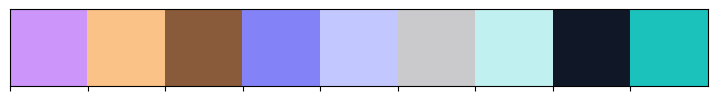

In [6]:
sns.palplot(custom_palette)
plt.show()

#Import Data

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Import%20Data.png)

I pulled the data from the US census.gov API for 2020-2024. It includes the total estimate of US Cocoa Bean Imports (weight in lbs, spend in $s), broken out by region/country:

Example URL:

https://api.census.gov/data/timeseries/intltrade/imports/enduse?get=CTY_CODE,CTY_NAME,I_ENDUSE,I_ENDUSE_LDESC,GEN_VAL_MO,CON_VAL_MO&I_ENDUSE=00010&YEAR=2013&MONTH=02

In [7]:
base_url = "https://api.census.gov/data/timeseries/intltrade/imports/enduse"
get_fields = "CTY_CODE,CTY_NAME,I_ENDUSE,I_ENDUSE_LDESC,GEN_VAL_MO,CON_VAL_MO,AIR_WGT_MO,CNT_WGT_MO,VES_WGT_MO"
I_ENDUSE = "00010"
start_year = 2020
end_year = 2024
months = range(1, 13)

all_data = []

for year in range(start_year, end_year + 1):
    for month in months:
        time_str = f"{year}-{month:02}"
        url = f"{base_url}?get={get_fields}&I_ENDUSE={I_ENDUSE}&time={time_str}"
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            headers = data[0]
            values = data[1:]
            all_data.extend(values)
        else:
            print(f"Error fetching {time_str}: {response.status_code}")

df = pd.DataFrame(all_data, columns=headers)
print(df)


     CTY_CODE            CTY_NAME I_ENDUSE I_ENDUSE_LDESC GEN_VAL_MO  \
0        6040    PAPUA NEW GUINEA    00010    COCOA BEANS    1825500   
1        2489             GRENADA    00010    COCOA BEANS       4172   
2        3010            COLOMBIA    00010    COCOA BEANS     254616   
3        3070           VENEZUELA    00010    COCOA BEANS     281799   
4        3310             ECUADOR    00010    COCOA BEANS    9281115   
...       ...                 ...      ...            ...        ...   
3018     2470  DOMINICAN REPUBLIC    00010    COCOA BEANS    8116783   
3019     7830            TANZANIA    00010    COCOA BEANS     105958   
3020     7880          MADAGASCAR    00010    COCOA BEANS     142291   
3021     2XXX     CENTRAL AMERICA    00010    COCOA BEANS    8116783   
3022     3XXX       SOUTH AMERICA    00010    COCOA BEANS   77767295   

     CON_VAL_MO AIR_WGT_MO CNT_WGT_MO VES_WGT_MO I_ENDUSE     time  
0       1825500          0     731520     731520    00010  2020-01

In [8]:
df.to_csv("us_cocoa_imports_2020_2024.csv", index=False)

Variables:

https://api.census.gov/data/timeseries/intltrade/imports/enduse/variables.html

Variable Dictionary:

In [9]:
variable_dict = {
  "CTY_CODE": "Country Code",
  "CTY_NAME": "Country Name",
  "I_ENDUSE": "Import End Use Code",
  "I_ENDUSE_LDESC": "Import End Use Long Description",
  "GEN_VAL_MO": "General Imports Total Value",
  "CON_VAL_MO": "Imports for Consumption, Total Value",
  "AIR_WGT_MO": "Air Shipping Weight",
  "CNT_WGT_MO": "Containerized Vessel Shipping Weight",
  "VES_WGT_MO": "Vessel Shipping Weight"}

In [10]:
print(tabulate(variable_dict.items(), headers=["Variable", "Description"]))

Variable        Description
--------------  ------------------------------------
CTY_CODE        Country Code
CTY_NAME        Country Name
I_ENDUSE        Import End Use Code
I_ENDUSE_LDESC  Import End Use Long Description
GEN_VAL_MO      General Imports Total Value
CON_VAL_MO      Imports for Consumption, Total Value
AIR_WGT_MO      Air Shipping Weight
CNT_WGT_MO      Containerized Vessel Shipping Weight
VES_WGT_MO      Vessel Shipping Weight


#Pre-Processing

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Pre-Processing.png)

The data was complete and there were no missing values:

There are ~3K monthly records for the timeframe that I pulled.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3023 entries, 0 to 3022
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CTY_CODE        3023 non-null   object
 1   CTY_NAME        3023 non-null   object
 2   I_ENDUSE        3023 non-null   object
 3   I_ENDUSE_LDESC  3023 non-null   object
 4   GEN_VAL_MO      3023 non-null   object
 5   CON_VAL_MO      3023 non-null   object
 6   AIR_WGT_MO      3023 non-null   object
 7   CNT_WGT_MO      3023 non-null   object
 8   VES_WGT_MO      3023 non-null   object
 9   I_ENDUSE        3023 non-null   object
 10  time            3023 non-null   object
dtypes: object(11)
memory usage: 259.9+ KB


Add "weight" variable, which is a combination of air, container, and vessel weights:

In [12]:
df["Weight"] = df["AIR_WGT_MO"].astype(int) + df["CNT_WGT_MO"].astype(int) + df["VES_WGT_MO"].astype(int)

Drop unneeded variables (country codes, cocoa beans code & description, consumption value (vs. general value) - only used for consumption vs. for anything, individual weights:

In [13]:
df.drop(columns=["CTY_CODE","I_ENDUSE","I_ENDUSE_LDESC","CON_VAL_MO","AIR_WGT_MO","CNT_WGT_MO","VES_WGT_MO"], inplace=True)

Rename country, spend, and month:

In [14]:
df.rename(columns={'CTY_NAME':'Country'}, inplace=True)
df.rename(columns={'GEN_VAL_MO':'Spend'}, inplace=True)
df.rename(columns={'time':'Import Date'}, inplace=True)

Change datatypes:

In [15]:
df['Import Date'] = pd.to_datetime(
    df['Import Date'],
    format='%Y-%m',
    errors='raise'
)

In [16]:
df['Year'] = df['Import Date'].dt.year

In [17]:
df['Month'] = df['Import Date'].dt.month

In [18]:
df['Spend']=df['Spend'].astype(int)

Add field for price per pound:

In [19]:
df['Price per Pound'] = df['Spend'] / df['Weight']

Field creation introducted NAs, fill NAs with 0:

In [20]:
df['Price per Pound']=df['Price per Pound'].fillna(0)

View country names:

In [21]:
df['Country'].unique()

array(['PAPUA NEW GUINEA', 'GRENADA', 'COLOMBIA', 'VENEZUELA', 'ECUADOR',
       'PERU', 'BRAZIL', 'FIJI', "COTE D'IVOIRE", 'GHANA',
       'DEMOCRATIC REPUBLIC OF THE CONGO', 'TOTAL FOR ALL COUNTRIES',
       'NORTH AMERICA', 'AFRICA', 'PACIFIC RIM COUNTRIES', 'CAFTA-DR',
       'AUSTRALIA AND OCEANIA', 'USMCA (NAFTA)',
       'TWENTY LATIN AMERICAN REPUBLICS', 'OECD', 'LAFTA', 'APEC', 'CACM',
       'MEXICO', 'GUATEMALA', 'COSTA RICA', 'DOMINICAN REPUBLIC',
       'TANZANIA', 'MADAGASCAR', 'CENTRAL AMERICA', 'SOUTH AMERICA',
       'CAMEROON', 'HAITI', 'INDIA', 'BOLIVIA', 'FRANCE', 'SWITZERLAND',
       'EUROPEAN UNION', 'EUROPE', 'ASIA', 'NATO', 'EURO AREA',
       'NICARAGUA', 'INDONESIA', 'PHILIPPINES', 'NIGERIA', 'CONGO',
       'ASEAN', 'NETHERLANDS', 'UGANDA', 'BELIZE', 'EL SALVADOR',
       'JAMAICA', 'TRINIDAD AND TOBAGO', 'HONDURAS', 'VIETNAM', 'TURKEY',
       'ITALY', 'CANADA', 'THAILAND', 'TOGO', 'BELGIUM', 'SIERRA LEONE',
       'MALAYSIA', 'GERMANY', 'CZECH REPUBLIC', '

In [22]:
df['Country'].nunique()

70

Identify groups of countries to remove, to keep only individual countries:

In [23]:
groups_to_remove = [
    "TOTAL FOR ALL COUNTRIES", "USMCA (NAFTA)", "OECD", "LAFTA", "APEC",
    "CACM", "EUROPEAN UNION", "EUROPE","AFRICA", "ASIA", "NATO", "EURO AREA", "ASEAN", "SOUTH AMERICA",
    'CENTRAL AMERICA', 'NORTH AMERICA',
    'AUSTRALIA AND OCEANIA',
    'EUROPEAN UNION', 'EURO AREA', 'NATO','TWENTY LATIN AMERICAN REPUBLICS',
    'PACIFIC RIM COUNTRIES'
]

df = df[~df["Country"].isin(groups_to_remove)]

Assign continent group to countries:

In [24]:
continent_map = {
    # Asia
    'INDONESIA': 'Asia', 'VIETNAM': 'Asia',
    'INDIA': 'Asia', 'THAILAND': 'Asia', 'PHILIPPINES': 'Asia', 'MALAYSIA': 'Asia',
    'TURKEY': 'Asia', #Turkey is 97% in Asia - 3% in Europe

    # Africa
    'CAMEROON': 'Africa', "COTE D'IVOIRE": 'Africa', 'GHANA': 'Africa', 'NIGERIA': 'Africa',
    'DEMOCRATIC REPUBLIC OF THE CONGO': 'Africa', 'CONGO': 'Africa', 'TANZANIA': 'Africa', 'UGANDA': 'Africa',
    'TOGO': 'Africa', 'SIERRA LEONE': 'Africa', 'MADAGASCAR': 'Africa',

    # Europe
    'NETHERLANDS': 'Europe', 'FRANCE': 'Europe', 'SWITZERLAND': 'Europe',
    'ITALY': 'Europe', 'BELGIUM': 'Europe', 'GERMANY': 'Europe', 'CZECH REPUBLIC': 'Europe', 'SPAIN': 'Europe',

    # North America
    'EL SALVADOR': 'North America', 'GRENADA': 'North America', 'PANAMA': 'North America',
    'CANADA': 'North America', 'MEXICO': 'North America', 'GUATEMALA': 'North America', 'HONDURAS': 'North America',
    'COSTA RICA': 'North America', 'HAITI': 'North America', 'DOMINICAN REPUBLIC': 'North America',
    'JAMAICA': 'North America',
    'TRINIDAD AND TOBAGO': 'North America', 'BELIZE': 'North America', 'NICARAGUA': 'North America',
    'CAFTA-DR': 'North America',

    # South America
    'ECUADOR': 'South America', 'PERU': 'South America', 'BRAZIL': 'South America', 'COLOMBIA': 'South America',
    'BOLIVIA': 'South America', 'VENEZUELA': 'South America',

    # Oceania
    'FIJI': 'Oceania', 'VANUATU': 'Oceania', 'SAMOA': 'Oceania', 'PAPUA NEW GUINEA': 'Oceania'

}

df['Continent'] = df['Country'].map(continent_map).fillna('Other')

print(df)

                 Country    Spend Import Date   Weight  Year  Month  \
0       PAPUA NEW GUINEA  1825500  2020-01-01  1463040  2020      1   
1                GRENADA     4172  2020-01-01     1090  2020      1   
2               COLOMBIA   254616  2020-01-01   151900  2020      1   
3              VENEZUELA   281799  2020-01-01   226802  2020      1   
4                ECUADOR  9281115  2020-01-01  6719234  2020      1   
...                  ...      ...         ...      ...   ...    ...   
3016          COSTA RICA        0  2024-12-01        0  2024     12   
3017               HAITI        0  2024-12-01        0  2024     12   
3018  DOMINICAN REPUBLIC  8116783  2024-12-01  2172360  2024     12   
3019            TANZANIA   105958  2024-12-01    25652  2024     12   
3020          MADAGASCAR   142291  2024-12-01    26648  2024     12   

      Price per Pound      Continent  
0            1.247744        Oceania  
1            3.827523  North America  
2            1.676208  South A

In [25]:
new_order = ['Continent','Country', 'Import Date', 'Month','Year', 'Weight', 'Price per Pound', 'Spend']

df = df[new_order]

In [26]:
df.head()

,Continent,Country,Import Date,Month,Year,Weight,Price per Pound,Spend
0,Oceania,PAPUA NEW GUINEA,2020-01-01,1,2020,1463040,1.247744,1825500
1,North America,GRENADA,2020-01-01,1,2020,1090,3.827523,4172
2,South America,COLOMBIA,2020-01-01,1,2020,151900,1.676208,254616
3,South America,VENEZUELA,2020-01-01,1,2020,226802,1.242489,281799
4,South America,ECUADOR,2020-01-01,1,2020,6719234,1.381276,9281115


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1906 entries, 0 to 3020
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Continent        1906 non-null   object        
 1   Country          1906 non-null   object        
 2   Import Date      1906 non-null   datetime64[ns]
 3   Month            1906 non-null   int32         
 4   Year             1906 non-null   int32         
 5   Weight           1906 non-null   int64         
 6   Price per Pound  1906 non-null   float64       
 7   Spend            1906 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(2), object(2)
memory usage: 119.1+ KB


There are ~19K records now with 51 countries:


In [28]:
df['Country'].nunique()

51

#EDA

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/EDA.png)

Total US Cocoa Bean Imports | Spend by Year:

Spend in 2024 (1.2B) was a close 2nd to the highest which was in 2021 (1.3B):

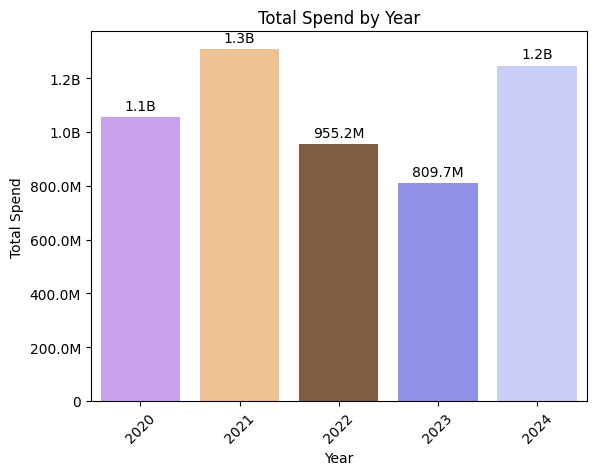

In [29]:
spend_by_year = df.groupby(['Year'])['Spend'].sum().reset_index()

def axis_format(x, pos=None):
    if x >= 1e12:
        return f'{x/1e12:.1f}T'
    elif x >= 1e9:
        return f'{x/1e9:.1f}B'
    elif x >= 1e6:
        return f'{x/1e6:.1f}M'
    else:
        return f'{x:.0f}'

ax = sns.barplot(
    data=spend_by_year,
    x='Year',
    y='Spend',
    hue='Year',
    palette=custom_palette[:5],
    legend=False
)

for container in ax.containers:
    labels = [axis_format(v) for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(axis_format))

plt.title('Total Spend by Year')
plt.ylabel('Total Spend')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.show()


Although spend was high, it was due to high prices. The volume (weight) actually had been trending down and was at the lowest in 5 years:

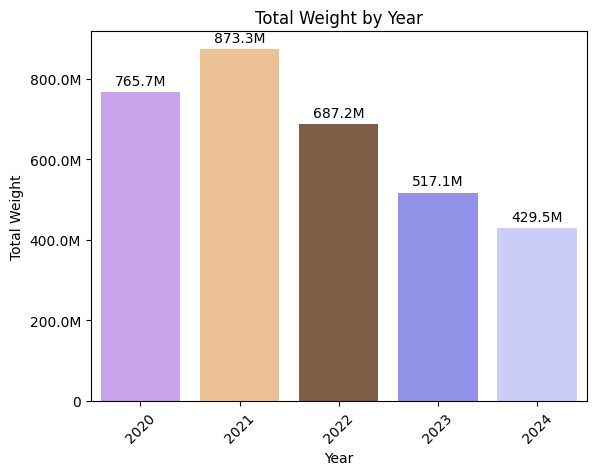

In [30]:
weight_by_year = df.groupby(['Year'])['Weight'].sum().reset_index()

def axis_format(x, pos=None):
    if x >= 1e12:
        return f'{x/1e12:.1f}T'
    elif x >= 1e9:
        return f'{x/1e9:.1f}B'
    elif x >= 1e6:
        return f'{x/1e6:.1f}M'
    else:
        return f'{x:.0f}'

ax = sns.barplot(
    data=weight_by_year,
    x='Year',
    y='Weight',
    hue='Year',
    palette=custom_palette[:5],
    legend=False
)

for container in ax.containers:
    labels = [axis_format(v) for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(axis_format))

plt.title('Total Weight by Year')
plt.ylabel('Total Weight')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.show()


Monthly aggregated chart of Spend, Price per Pound, & Weight:

In [31]:
monthly_df = (
    df
    .groupby('Import Date', as_index=False)
    .agg({
        'Weight': 'sum',
        'Spend': 'sum'
    })
)

monthly_df['Price per Pound'] = monthly_df['Spend'] / monthly_df['Weight']
monthly_df['Year'] = monthly_df['Import Date'].dt.year
monthly_df['Month'] = monthly_df['Import Date'].dt.strftime('%b')


In [32]:
monthly_df.head()

,Import Date,Weight,Spend,Price per Pound,Year,Month
0,2020-01-01,77863938,110827113,1.423343,2020,Jan
1,2020-02-01,118967413,183396139,1.541566,2020,Feb
2,2020-03-01,117594405,160633331,1.365995,2020,Mar
3,2020-04-01,72523979,109295892,1.507031,2020,Apr
4,2020-05-01,58180114,71059481,1.221371,2020,May


US Cocoa Bean Imports YOY | Spend:

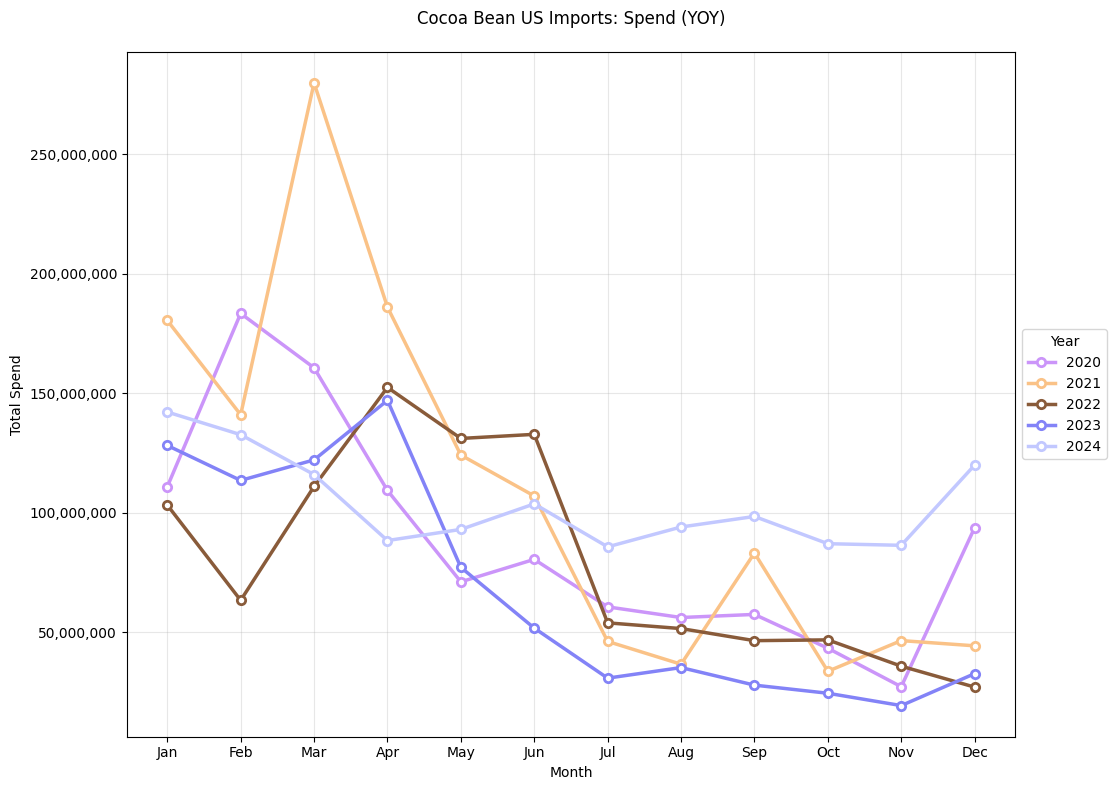

In [33]:
plt.figure(figsize=(12, 8))

for i, year in enumerate(monthly_df['Year'].unique()):
    year_data = monthly_df[monthly_df['Year'] == year]
    plt.plot(year_data['Month'], year_data['Spend'],
             marker='o', linewidth=2.5, markersize=6,
             color=custom_palette[i % len(custom_palette)],
             label=str(year), markerfacecolor='white',
             markeredgewidth=2)

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Cocoa Bean US Imports: Spend (YOY)', pad=20)
plt.xlabel('Month')
plt.ylabel('Total Spend')
plt.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()


US Cocoa Bean Imports YOY | Price per Pound:

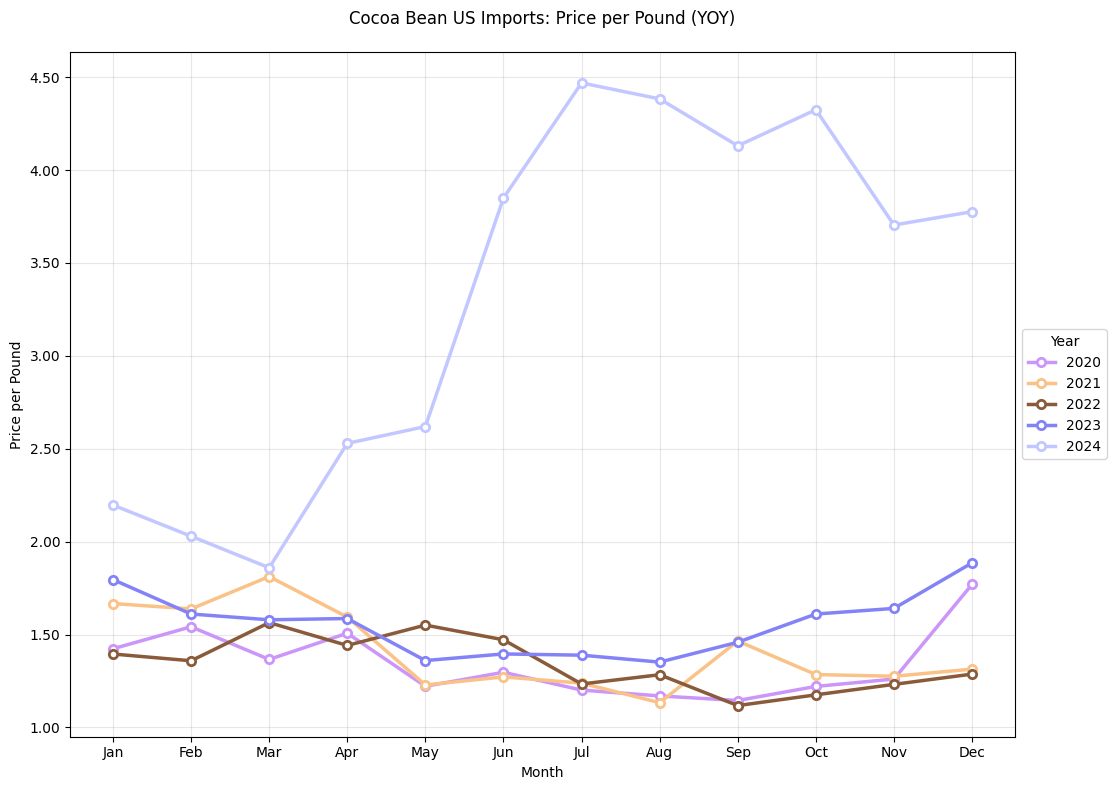

In [34]:
plt.figure(figsize=(12, 8))

for i, year in enumerate(monthly_df['Year'].unique()):
    year_data = monthly_df[monthly_df['Year'] == year]
    plt.plot(year_data['Month'], year_data['Price per Pound'],
             marker='o', linewidth=2.5, markersize=6,
             color=custom_palette[i % len(custom_palette)],
             label=str(year), markerfacecolor='white',
             markeredgewidth=2)

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.2f}'))
plt.title('Cocoa Bean US Imports: Price per Pound (YOY)', pad=20)
plt.xlabel('Month')
plt.ylabel('Price per Pound')
plt.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()


US Cocoa Bean Imports YOY | Weight:

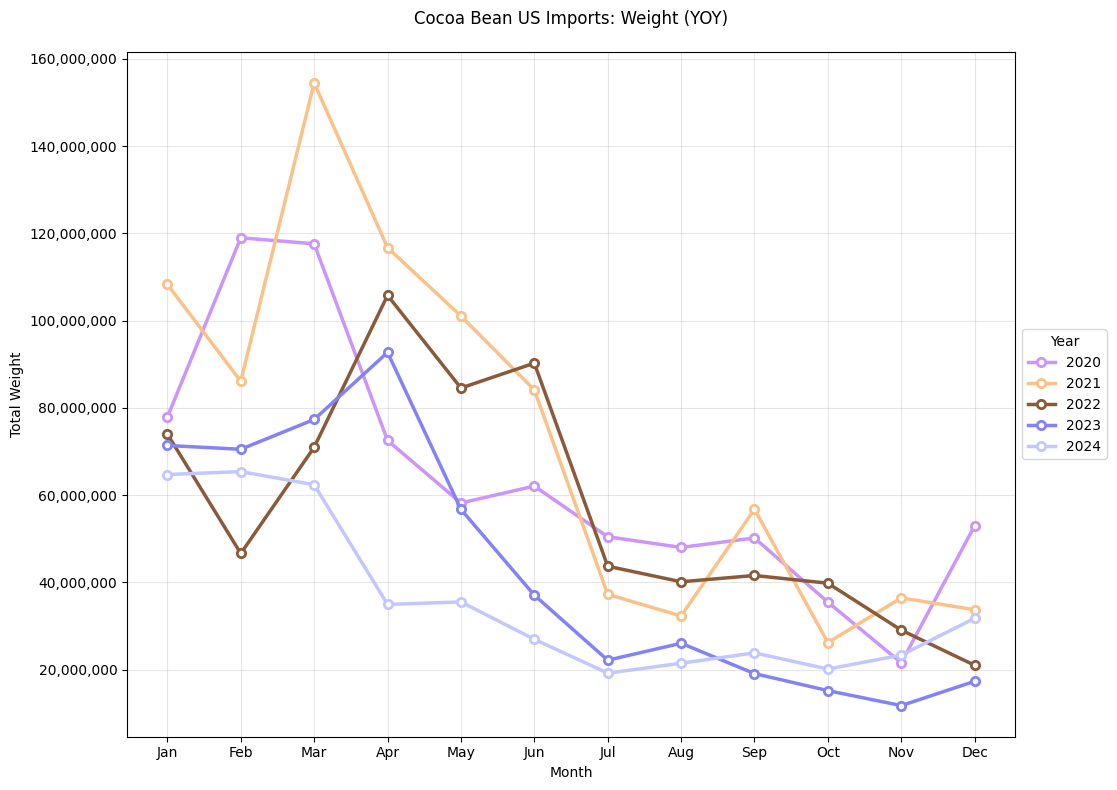

In [35]:
plt.figure(figsize=(12, 8))

for i, year in enumerate(monthly_df['Year'].unique()):
    year_data = monthly_df[monthly_df['Year'] == year]
    plt.plot(year_data['Month'], year_data['Weight'],
             marker='o', linewidth=2.5, markersize=6,
             color=custom_palette[i % len(custom_palette)],
             label=str(year), markerfacecolor='white',
             markeredgewidth=2)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Cocoa Bean US Imports: Weight (YOY)', pad=20)
plt.xlabel('Month')
plt.ylabel('Total Weight')
plt.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()


#Decomposition

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Decomposition.png)

I first performed decomposition on the data to get an idea of its components (trend, seasonality, residuals):

Run sequence plots:

These charts are continuous time series that show the pattern of the data in one sequence (vs. YOY, etc.). They are a good visual to see if there is a trend, seasonality, etc.

In [36]:
def run_sequence_plot(x, y, title, xlabel="time", ylabel="series", width=13, height=4):
    plt.figure(figsize=(width, height))
    plt.plot(x, y, 'k-')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.show()

The Weight and Spend show strong seasonal patterns:

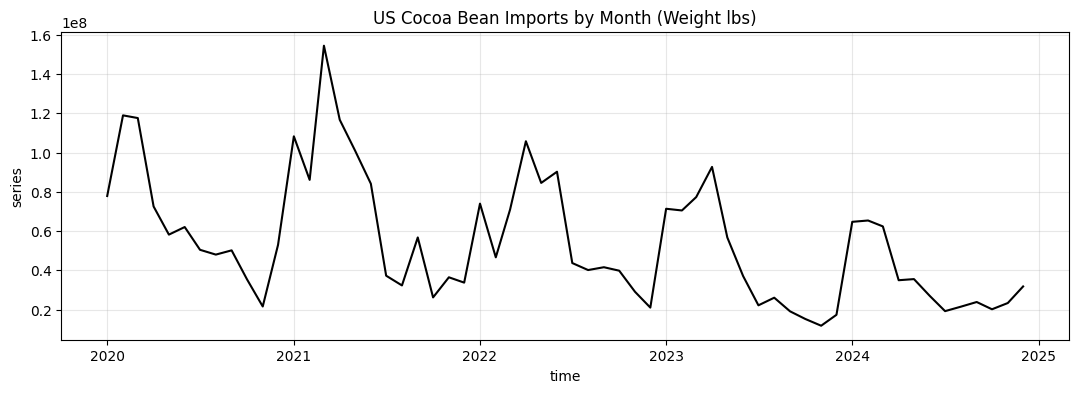

In [37]:
run_sequence_plot(monthly_df['Import Date'], monthly_df['Weight'],
                  title="US Cocoa Bean Imports by Month (Weight lbs)")

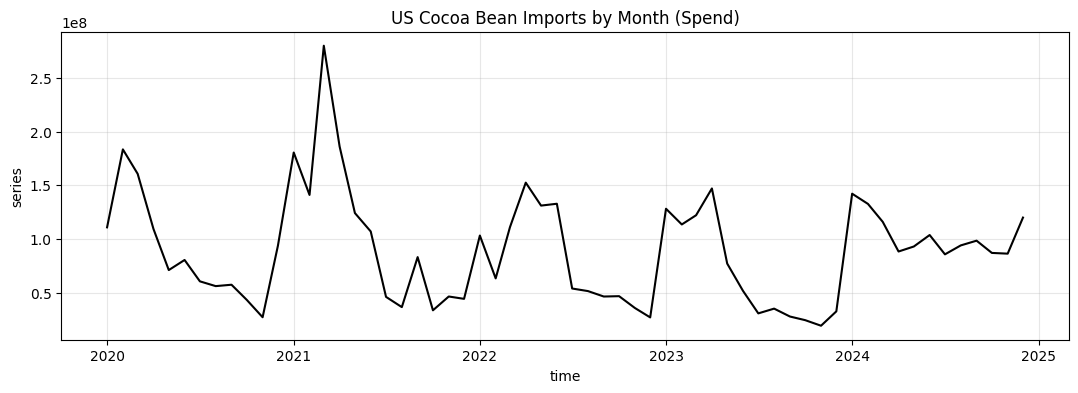

In [38]:
run_sequence_plot(monthly_df['Import Date'], monthly_df['Spend'],
                  title="US Cocoa Bean Imports by Month (Spend)")

The Price shows a strong upward trend:

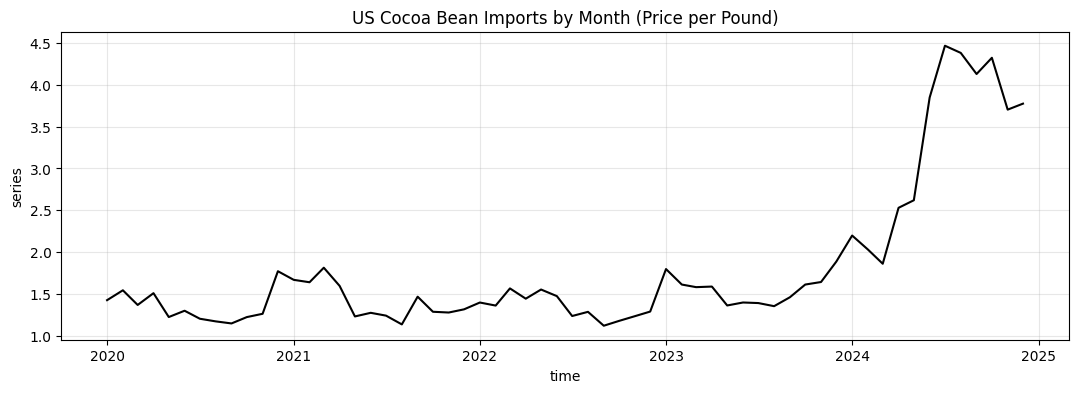

In [39]:
run_sequence_plot( monthly_df['Import Date'],  monthly_df['Price per Pound'],
                  title="US Cocoa Bean Imports by Month (Price per Pound)")

Transformations (to remove trend and seasonality):

Full decomposition for Weight (breaks out run sequence, trend, seasonality, residuals):

In [40]:
data = monthly_df.set_index('Import Date')['Weight']

In [41]:
display(data.head())

,Weight
Import Date,
2020-01-01,77863938
2020-02-01,118967413
2020-03-01,117594405
2020-04-01,72523979
2020-05-01,58180114


Period: 12 for yearly seasonality:

In [42]:
ss_decomposition = seasonal_decompose(x=data, model='additive', period=12)
estimated_trend = ss_decomposition.trend
estimated_seasonal = ss_decomposition.seasonal
estimated_residual = ss_decomposition.resid

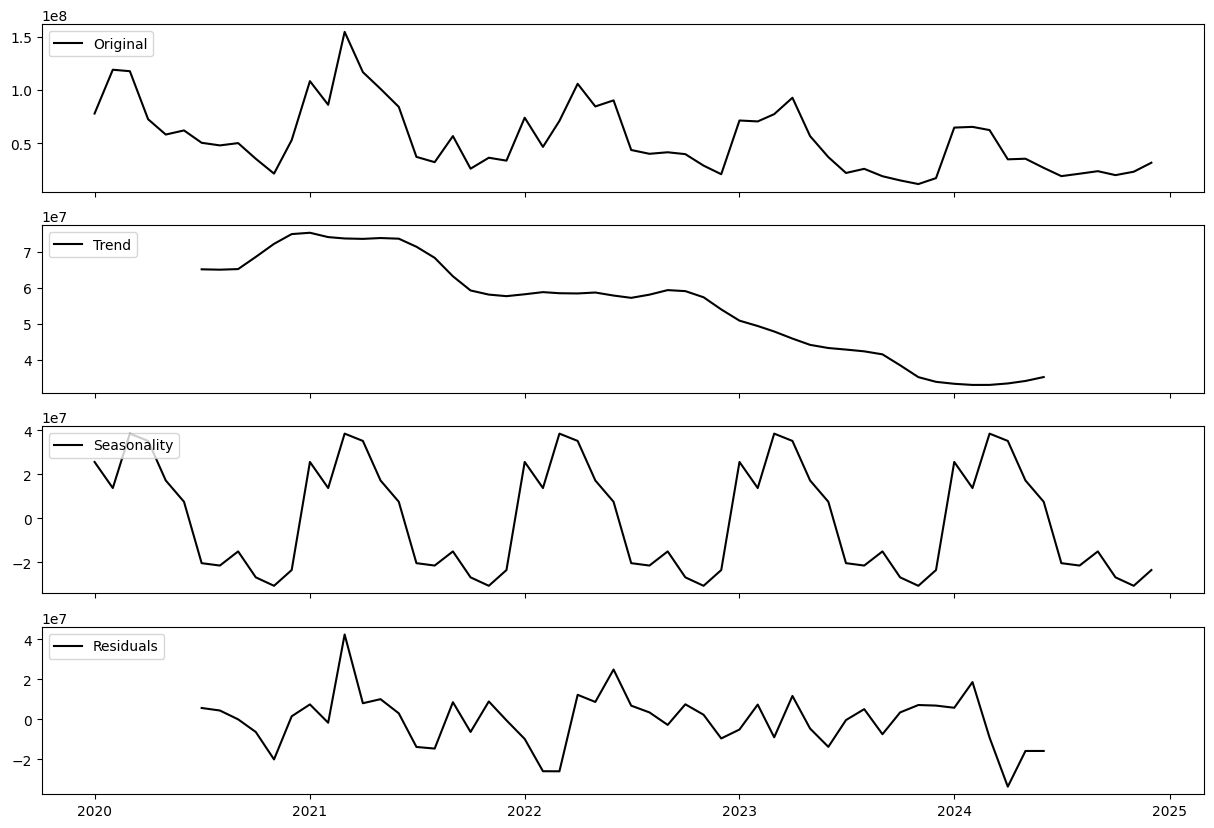

In [43]:
fig, axes = plt.subplots(4, 1, sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(data, label='Original', color='black')
axes[0].legend(loc='upper left')

axes[1].plot(estimated_trend, label='Trend', color='black')
axes[1].legend(loc='upper left')

axes[2].plot(estimated_seasonal, label='Seasonality', color='black')
axes[2].legend(loc='upper left')

axes[3].plot(estimated_residual, label='Residuals', color='black')
axes[3].legend(loc='upper left')


(The first chart in the group is the run sequence again)

Trend: The trend would be an increasing or decreasing slope over time (upward vs. downward). This shows a downward trend in cocoa bean imports over time.

Seasonality: Seasonality would be repeated, periodic patterns over time. This chart shows that for the most part there are peaks at the beginning of each year for cocoa bean imports and it drops throughout the year.

Residuals: The left-over fluctuations after removing the trend & seasonality, These appear pretty random and uncorrelated for the most part. When they are random, correlated, normally distributed and have a mean around 0, it means that the trend and seasonality have effectively been identified and removed from the data. Here the mean is around 0, and there is no trend or seasonality left and the mean is constant.

Plotting the residuals in a histograms shows that they roughly follow a normal distribution:

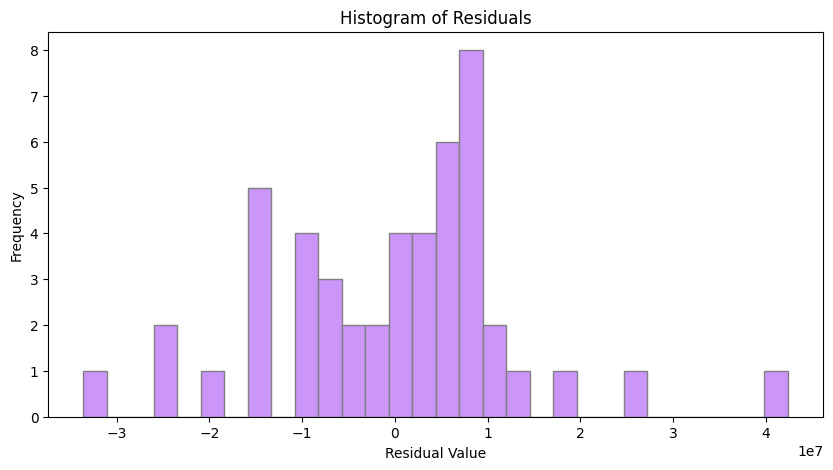

In [44]:
plt.figure(figsize=(10, 5))
plt.hist(estimated_residual, bins=30, color=custom_palette[0], edgecolor='gray')
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.show()

The first and last 6 values of the residuals are NaN and are removed:

In [45]:
print(estimated_residual[-6:])

Import Date
2024-07-01   NaN
2024-08-01   NaN
2024-09-01   NaN
2024-10-01   NaN
2024-11-01   NaN
2024-12-01   NaN
Name: resid, dtype: float64


In [46]:
print(estimated_residual[:6])

Import Date
2020-01-01   NaN
2020-02-01   NaN
2020-03-01   NaN
2020-04-01   NaN
2020-05-01   NaN
2020-06-01   NaN
Name: resid, dtype: float64


Autocorrelation: Autocorrelation shows if there is a correlation between previous periods. This shows 12 lags since the data is monthly. There is significant (outside the blue) correlation with the 1st 3 months and the 12th month.

(Ignore Lag 0: always shows up and is equal to 1 because lags are a correlation with  the current value, and 0 is the current value, so it will be 1)

Lags 1-2: means that the values for today are correlated to those for last month, & 2 months ago. Lag 12: means the values for today are correlated to those from 12 months ago. High autocorrelation at smaller lags and slow decay is representative of a trend.

I plotted 24 lags to see if there is a seasonality cycle longer than 12, but there is not. 12 is the last significant lag, so the period for the decomposition should remain at 12 for annual seasonality.

Lags 1, 2 & 12 are significant for autocorrelation, but looking at the partial autocorrelation where it removes the dependence on the previous lag, only 1 and 12 are significant, showing that the current value is correlated with the previous value (AR1) and the value 12 months ago (seasonal AR term since data is monthly).

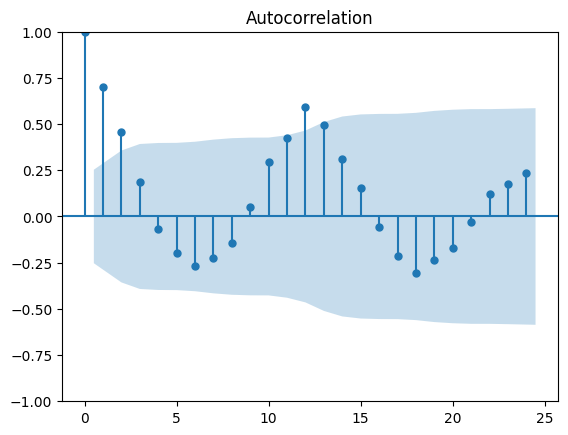

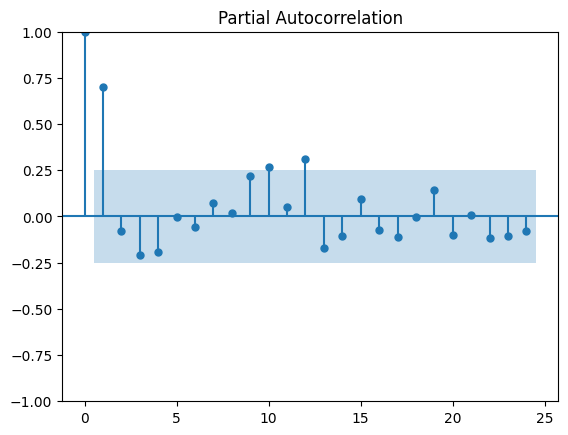

In [47]:
plot_acf(data, lags=24)
plot_pacf(data, lags=24)
plt.show()

In [48]:
residuals_final = estimated_residual[6:-6]
#same as estimated_residual.dropna()

Residuals show autocorrelation at lag 4, which I gave the option to be modeled in SARIMA later (turned stepwise off and allowed it to go up to 4) but a model including this lag was not the best performer, so this effect was not as important:

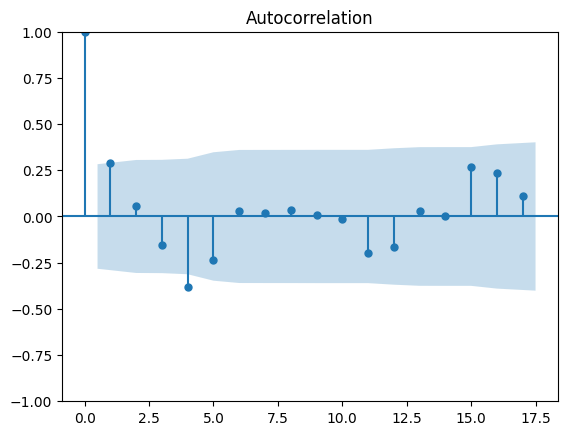

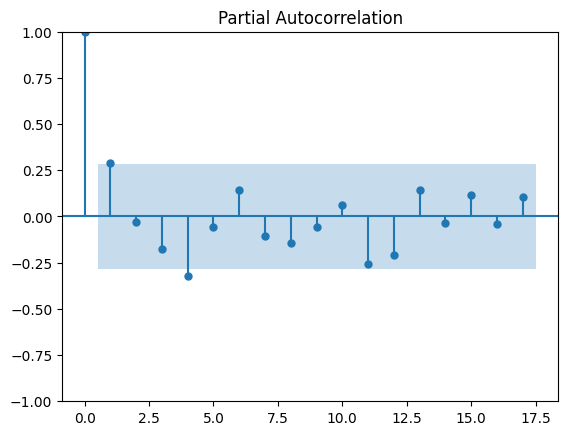

In [49]:
plot_acf(residuals_final)
plot_pacf(residuals_final)
plt.show()

The Dickey Fuller Test confirms the original data is non-stationary as we cannot reject the null that the data is non-stationary:

(Stationary data would have constant mean & variance, no autocorrelation, and no periodic component)

In [50]:
adf_b4, pvalue_b4, usedlag_, nobs_, critical_values_, icbest_ = adfuller(data)
print(f"ADF: {adf_b4:.6f}")
print(f"p-value: {pvalue_b4:.9f}")

ADF: 0.021728
p-value: 0.960292504


Test the residuals for stationarity (after removing 1st and last 6 values since they're NaN):

After removing the trend and seasonality, the residuals are stationary (p-value <0.05) and no further differencing is needed, therefore this decomposition adquately captures the patterns in the data as a good way to understand it:

In [51]:
adf_b4, pvalue_b4, usedlag_, nobs_, critical_values_, icbest_ = adfuller(residuals_final)
print(f"ADF: {adf_b4:.6f}")
print(f"p-value: {pvalue_b4:.9f}")

ADF: -4.862790
p-value: 0.000041182


#Models

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Models.png)

##Model 1: Smoothing

I first performed Smoothing as a model option/baseline. I chose Triple Exponential Smoothing, as that is the best option when there is both trend and seasonality.

Smoothing calculates a moving average in order to reduce noise. Exponential Smoothing weights the more recent lags more heavily. Triple Exponential Smoothing includes 3 components to smooth the value, the trend, and the seasonality.

In [52]:
monthly_df.head()

,Import Date,Weight,Spend,Price per Pound,Year,Month
0,2020-01-01,77863938,110827113,1.423343,2020,Jan
1,2020-02-01,118967413,183396139,1.541566,2020,Feb
2,2020-03-01,117594405,160633331,1.365995,2020,Mar
3,2020-04-01,72523979,109295892,1.507031,2020,Apr
4,2020-05-01,58180114,71059481,1.221371,2020,May


In [53]:
data = pd.DataFrame({
    'Import Date': monthly_df['Import Date'],
    'Weight': monthly_df['Weight']
})


In [54]:
data.head()

,Import Date,Weight
0,2020-01-01,77863938
1,2020-02-01,118967413
2,2020-03-01,117594405
3,2020-04-01,72523979
4,2020-05-01,58180114


In [55]:
train = data[:-5]
test = data[-5:]

In [56]:
triple = ExponentialSmoothing(train['Weight'],
                              trend="additive",damped_trend=True,
                              seasonal="additive",
                              seasonal_periods=12).fit(optimized=True)
triple_preds = triple.forecast(len(test['Weight']))

The untuned Exponential Smoothing performs very poorly, greatly overestimating the downward trend:

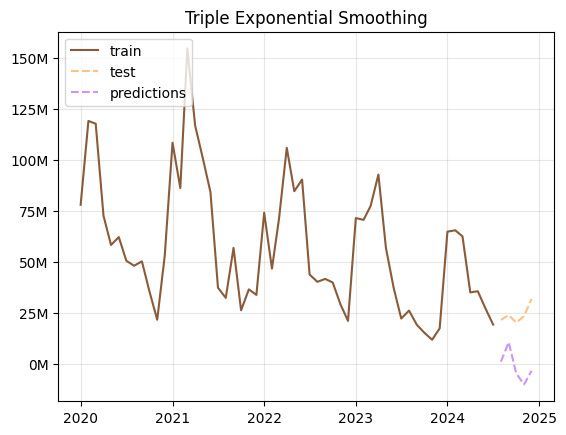

In [57]:
plt.plot(train['Import Date'], train['Weight'], color=custom_palette[2], label="train")
plt.plot(test['Import Date'], test['Weight'], color=custom_palette[1], linestyle="--", label="test")
plt.plot(test['Import Date'], triple_preds, color=custom_palette[0], linestyle="--", label="predictions")

def millions(x, pos):
    return f'{int(x/1e6)}M'

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

plt.legend(loc='upper left')
plt.title("Triple Exponential Smoothing")
plt.grid(alpha=0.3)
plt.show()


Below is a Rolling CV for the model. It forecasts a 3 month horizon (add one month, predict 3 month out, add another month, predict again, etc.) starting with a cutoff of 45 months (Sep '23) and predicting through the 60th month of data (Dec '24):

Reported are the forecast vs. actual (yhat vs. y) and the absolute error (difference btw those two) and the absoluate percentage error (error/actual):

In [58]:
horizon = 3
exp_ts_results = []

for cutoff in range(44, 60):
    if cutoff + horizon >= len(data):
        break

    train_series = data['Weight'].iloc[:cutoff + 1]

    triple = ExponentialSmoothing(
        train_series,
        trend="additive", damped_trend=True,
        seasonal="additive", seasonal_periods=12
    ).fit(optimized=True)

    yhat = triple.forecast(steps=horizon)
    y_true = data['Weight'].iloc[cutoff + 1 : cutoff + 1 + horizon]

    for h in range(horizon):
        ae = abs(yhat.iloc[h] - y_true.iloc[h])
        ape = ae / max(abs(y_true.iloc[h]), 1e-8)

        exp_ts_results.append({
            'cutoff': cutoff,
            'horizon': h + 1,
            'cutoff_month': data['Import Date'].iloc[cutoff].to_period('M').to_timestamp(),
            'month': data['Import Date'].iloc[cutoff + h + 1].to_period('M').to_timestamp(),
            'y': y_true.iloc[h],
            'yhat': yhat.iloc[h],
            'AE': ae,
            'APE': ape
        })

exp_ts_cv_df = pd.DataFrame(exp_ts_results)

exp_ts_cv_df.style.format({
    'cutoff_month': '{:%m-%d-%Y}',
    'month': '{:%m-%d-%Y}',
    'y': '{:,.0f}',
    'yhat': '{:,.0f}',
    'AE': '{:,.0f}',
    'APE': '{:.0%}'
})


,cutoff,horizon,cutoff_month,month,y,yhat,AE,APE
0,44,1,09-01-2023,10-01-2023,"15,172,388","6,900,955","8,271,433",55%
1,44,2,09-01-2023,11-01-2023,"11,741,002","3,753,794","7,987,208",68%
2,44,3,09-01-2023,12-01-2023,"17,305,596","16,756,673","548,923",3%
3,45,1,10-01-2023,11-01-2023,"11,741,002","6,045,764","5,695,238",49%
4,45,2,10-01-2023,12-01-2023,"17,305,596","19,019,787","1,714,191",10%
5,45,3,10-01-2023,01-01-2024,"64,702,033","66,345,084","1,643,051",3%
6,46,1,11-01-2023,12-01-2023,"17,305,596","20,419,931","3,114,335",18%
7,46,2,11-01-2023,01-01-2024,"64,702,033","67,744,085","3,042,052",5%
8,46,3,11-01-2023,02-01-2024,"65,375,575","44,310,486","21,065,089",32%
9,47,1,12-01-2023,01-01-2024,"64,702,033","65,781,484","1,079,451",2%


The MAPEs (mean absolute percentage error) are very high and increase from the one month out prediction to the 3 month out prediction:

In [59]:
exp_ts_cv = exp_ts_cv_df.groupby('horizon').agg(
    MAE=('AE', 'mean'),
    MAPE=('APE', 'mean'))

exp_ts_cv.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"14,215,908",52%
2,"18,849,734",69%
3,"22,905,085",79%


The overall MAPE for the whole model is 68% which is very high:

In [60]:
exp_ts_overall_MAE  = exp_ts_cv_df['AE'].mean()
exp_ts_overall_MAPE = exp_ts_cv_df['APE'].mean()

print(f"MAE: {exp_ts_overall_MAE:,.0f}")
print(f"MAPE (%): {exp_ts_overall_MAPE:.0%}")

MAE: 18,656,909
MAPE (%): 67%


Plot forecast (yhat) vs. actuals (y) for ALL data (not just a train/test split like above) to see model fit:

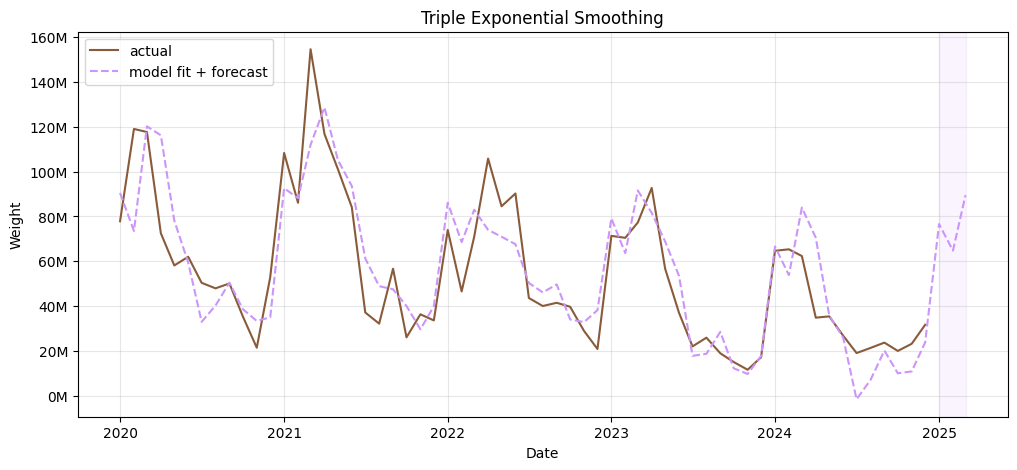

In [61]:
triple = ExponentialSmoothing(
    data['Weight'],
    trend="additive", damped_trend=True,
    seasonal="additive", seasonal_periods=12
).fit(optimized=True)

fitted = triple.fittedvalues

forecast_steps = 3
forecast = triple.forecast(steps=forecast_steps)

last_date = data['Import Date'].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq='MS'
)

combined_preds = np.concatenate([fitted.values, forecast.values])
combined_dates = pd.concat([data['Import Date'], pd.Series(future_dates)], ignore_index=True)

plt.figure(figsize=(12, 5))

plt.plot(data['Import Date'], data['Weight'], color=custom_palette[2], label="actual")

plt.plot(combined_dates, combined_preds, color=custom_palette[0], linestyle='--', label="model fit + forecast")

plt.axvspan(future_dates[0], future_dates[-1], color=custom_palette[0], alpha=0.1)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))

plt.legend(loc='upper left')
plt.title("Triple Exponential Smoothing")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(alpha=0.3)
plt.show()


I moved to tuning the Triple Exponential Smoothing by making the seasonality multiplicative. It does look like it has a fair multiplicative effect in that the seasonality jumps look like they decrease in magnitude with time. This adjustment does improve the model greatly:

In [62]:
triple_tuned = ExponentialSmoothing(train['Weight'],
                              trend="additive",damped_trend=True,
                              seasonal="multiplicative",
                              seasonal_periods=12).fit(optimized=True)
triple_tuned_preds = triple_tuned.forecast(len(test['Weight']))

The forecast for the last 3 months greatly improves vs. the previous untuned version:

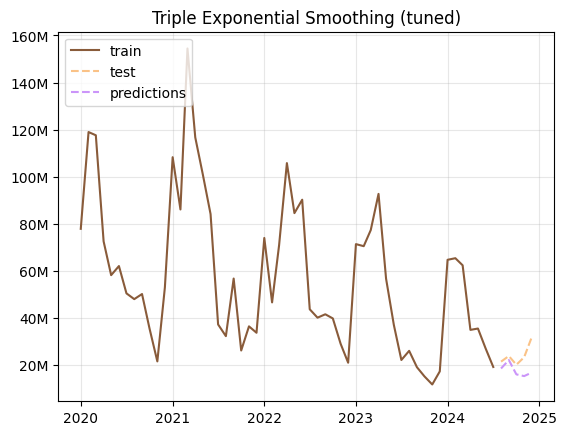

In [63]:
plt.plot(train['Import Date'], train['Weight'], color=custom_palette[2], label="train")
plt.plot(test['Import Date'], test['Weight'], color=custom_palette[1], linestyle="--", label="test")
plt.plot(test['Import Date'], triple_tuned_preds, color=custom_palette[0], linestyle="--", label="predictions")

def millions(x, pos):
    return f'{int(x/1e6)}M'

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

plt.legend(loc='upper left')
plt.title("Triple Exponential Smoothing (tuned)")
plt.grid(alpha=0.3)
plt.show()

In [64]:
horizon = 3
exp_ts_tuned_results = []

for cutoff in range(44, 60):
    if cutoff + horizon >= len(data):
        break

    train = data['Weight'].iloc[:cutoff + 1]

    triple_tuned = ExponentialSmoothing(
        train,
        trend="additive", damped_trend=True,
        seasonal="multiplicative", seasonal_periods=12
    ).fit(optimized=True)

    yhat = triple_tuned.forecast(steps=horizon)
    y_true = data['Weight'].iloc[cutoff + 1 : cutoff + 1 + horizon]

    for h in range(horizon):
        ae = abs(yhat.iloc[h] - y_true.iloc[h])
        ape = ae / max(abs(y_true.iloc[h]), 1e-8)

        exp_ts_tuned_results.append({
            'cutoff': cutoff,
            'horizon': h + 1,
            'cutoff_month': data['Import Date'].iloc[cutoff].to_period('M').to_timestamp(),
            'month': data['Import Date'].iloc[cutoff + h + 1].to_period('M').to_timestamp(),
            'y': y_true.iloc[h],
            'yhat': yhat.iloc[h],
            'AE': ae,
            'APE': ape
        })

exp_ts_tuned_cv_df = pd.DataFrame(exp_ts_tuned_results)
exp_ts_tuned_cv_df.style.format({
    'cutoff_month': '{:%m-%d-%Y}',
    'month': '{:%m-%d-%Y}',
    'y': '{:,.0f}',
    'yhat': '{:,.0f}',
    'AE': '{:,.0f}',
    'APE': '{:.0%}'
})

,cutoff,horizon,cutoff_month,month,y,yhat,AE,APE
0,44,1,09-01-2023,10-01-2023,"15,172,388","19,758,980","4,586,592",30%
1,44,2,09-01-2023,11-01-2023,"11,741,002","18,827,435","7,086,433",60%
2,44,3,09-01-2023,12-01-2023,"17,305,596","20,571,931","3,266,335",19%
3,45,1,10-01-2023,11-01-2023,"11,741,002","17,314,660","5,573,658",47%
4,45,2,10-01-2023,12-01-2023,"17,305,596","18,983,433","1,677,837",10%
5,45,3,10-01-2023,01-01-2024,"64,702,033","44,986,140","19,715,893",30%
6,46,1,11-01-2023,12-01-2023,"17,305,596","16,869,278","436,318",3%
7,46,2,11-01-2023,01-01-2024,"64,702,033","39,890,378","24,811,655",38%
8,46,3,11-01-2023,02-01-2024,"65,375,575","39,351,745","26,023,830",40%
9,47,1,12-01-2023,01-01-2024,"64,702,033","40,252,573","24,449,460",38%


The MAPEs drastically decrease and fall in an acceptable range (20-30%) for volatile, seasonal data:

In [65]:
exp_ts_tuned_cv = exp_ts_tuned_cv_df.groupby('horizon').agg(
    MAE=('AE', 'mean'),
    MAPE=('APE', 'mean'))

exp_ts_tuned_cv.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"8,232,452",24%
2,"9,662,805",29%
3,"10,782,135",30%


The overall MAPE is 27%:

In [66]:
exp_ts_tuned_overall_MAE  = exp_ts_tuned_cv_df['AE'].mean()
exp_ts_tuned_overall_MAPE = exp_ts_tuned_cv_df['APE'].mean()
print(f"MAE: {exp_ts_tuned_overall_MAE:,.0f}")
print(f"MAPE: {exp_ts_tuned_overall_MAPE:.0%}")

MAE: 9,559,131
MAPE: 27%


I want to see the full fitted model (fit vs. actual) and the forecast (shaded region) together, so I plot them below:

Fitted values : “What would I have predicted historically?”

Forecasts: “What do I predict now?”

The model fit looks very good given the volatility:

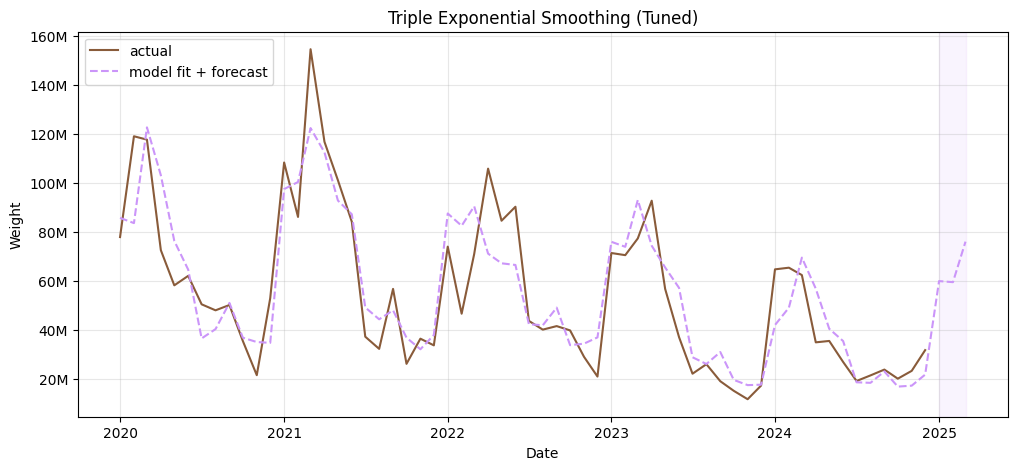

In [67]:
triple_tuned = ExponentialSmoothing(
    data['Weight'],
    trend="additive",
    damped_trend=True,
    seasonal="multiplicative",
    seasonal_periods=12
).fit(optimized=True)

fitted = triple_tuned.fittedvalues

forecast_steps = 3
forecast = triple_tuned.forecast(steps=forecast_steps)

last_date = data['Import Date'].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq='MS'
)

combined_preds = np.concatenate([fitted.values, forecast.values])
combined_dates = pd.concat([data['Import Date'], pd.Series(future_dates)], ignore_index=True)

plt.figure(figsize=(12, 5))

plt.plot(data['Import Date'], data['Weight'], color=custom_palette[2], label="actual")

plt.plot(combined_dates, combined_preds, color=custom_palette[0], linestyle='--', label="model fit + forecast")

plt.axvspan(future_dates[0], future_dates[-1], color=custom_palette[0], alpha=0.1)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))

plt.legend(loc='upper left')
plt.title("Triple Exponential Smoothing (Tuned)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(alpha=0.3)
plt.show()


The Exponential Smoothing model does not provide Confidence Intervals, so I have manually bootstrapped them below (and later switch to ETS to replicate and report their built-in CI as another option):

Bootstrapped CI:

 Note, I changed the CI to 80% to get a narrower forecast range which in this case with the CI being so wide would be practical. This is consistent with the default CI from Prophet. The 95% CIs were very wide and uninformative.

In [68]:
def bootstrap_hw_intervals(model,train_values, horizon, n_boot=500):
    residuals = model.resid
    forecasts = np.zeros((n_boot, horizon))

    for i in range(n_boot):
        boot_sample = train_values + np.random.choice(residuals, size=len(train_values))
        boot_sample = np.maximum(boot_sample, 1e-6)

        boot_model = ExponentialSmoothing(
            boot_sample,
            trend="additive",
            damped_trend=True,
            seasonal="multiplicative",
            seasonal_periods=12
        ).fit(optimized=True)

        forecasts[i, :] = boot_model.forecast(steps=horizon)

    lower = np.percentile(forecasts, 10, axis=0)
    upper = np.percentile(forecasts, 90, axis=0)

    return pd.DataFrame({
        'horizon': range(1, horizon + 1),
        'point_forecast': model.forecast(steps=horizon),
        'ci_lower': lower,
        'ci_upper': upper
    })


Fit Holt-Winters Exponential Smoothing on full history:

In [69]:
np.random.seed(42)

train_values = data['Weight'].values
final_hw = ExponentialSmoothing(
    train_values,
    trend="additive", damped_trend=True,
    seasonal="multiplicative", seasonal_periods=12
).fit(optimized=True)

ci_df = bootstrap_hw_intervals(final_hw, train_values, horizon=3, n_boot=500)

In [70]:
ci_df.style.format("{:,.0f}")

,horizon,point_forecast,ci_lower,ci_upper
0,1,"59,915,879","31,650,288","67,112,956"
1,2,"59,477,191","30,411,928","65,506,480"
2,3,"75,993,848","38,341,516","84,996,331"


In [71]:
future_dates = pd.date_range(
    start=data['Import Date'].iloc[-1] + pd.offsets.MonthBegin(1),
    periods=3,
    freq='MS'
)

forecast_table = pd.DataFrame({
    'Date': future_dates,
    'Forecast': ci_df['point_forecast'].round().astype(int),
    'Lower_80%_CI': np.floor(ci_df['ci_lower']).astype(int),
    'Upper_80%_CI': np.ceil(ci_df['ci_upper']).astype(int)
})
print(forecast_table)


        Date  Forecast  Lower_80%_CI  Upper_80%_CI
0 2025-01-01  59915879      31650287      67112957
1 2025-02-01  59477191      30411927      65506481
2 2025-03-01  75993848      38341516      84996332


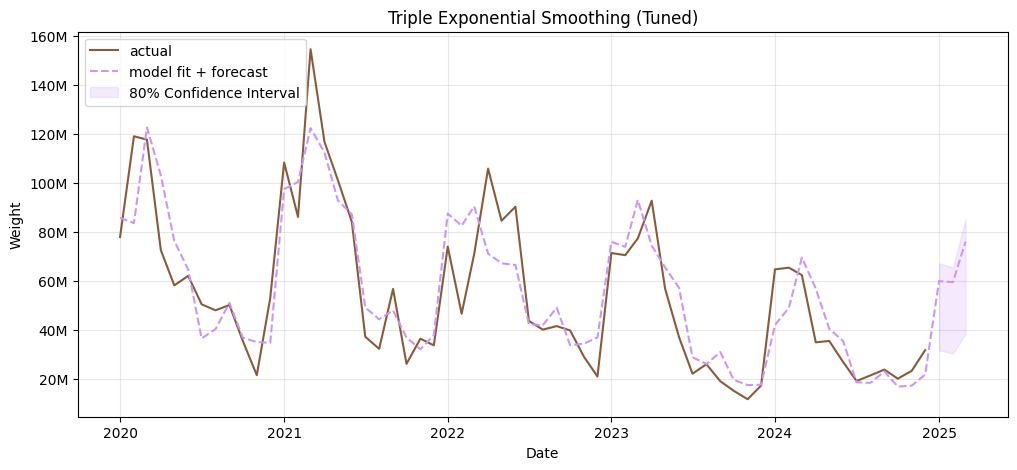

In [72]:
triple_tuned = ExponentialSmoothing(
    data['Weight'],
    trend="additive",
    damped_trend=True,
    seasonal="multiplicative",
    seasonal_periods=12
).fit(optimized=True)

fitted = triple_tuned.fittedvalues
forecast_steps = 3
forecast = triple_tuned.forecast(steps=forecast_steps)

last_date = data['Import Date'].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq='MS'
)

combined_preds = np.concatenate([fitted.values, forecast.values])
combined_dates = pd.concat([data['Import Date'], pd.Series(future_dates)], ignore_index=True)

plt.figure(figsize=(12, 5))
plt.plot(data['Import Date'], data['Weight'], color=custom_palette[2], label="actual")
plt.plot(combined_dates, combined_preds, color=custom_palette[0], linestyle='--',
         label="model fit + forecast")

plt.fill_between(
    future_dates,
    ci_df['ci_lower'].values,
    ci_df['ci_upper'].values,
    color=custom_palette[0],
    alpha=0.2,
    label='80% Confidence Interval'
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))
plt.legend(loc='upper left')
plt.title("Triple Exponential Smoothing (Tuned)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(alpha=0.3)
plt.show()


Since the Exponential Smoothing Model (Holt Winters) does not have built-in confidence intervals and I manually bootstrapped them above, I also tested out the ETS Model to closely replicate the model and add the CI from it built-in functionality (as a secondary gut check to my CI):

In [73]:
horizon = 3
ets_tuned_results = []

for cutoff in range(44, 60):
    if cutoff + horizon >= len(data):
        break

    train = data['Weight'].iloc[:cutoff + 1]

    triple_tuned_ets = ETSModel(
        endog=train,
        error='add',
        trend='add',
        damped_trend=True,
        seasonal='mul',
        seasonal_periods=12,
    ).fit(optimized=True)

    yhat = triple_tuned_ets.forecast(steps=horizon)

    pred = triple_tuned_ets.get_prediction(start=len(train), end=len(train)+horizon-1)
    sf = pred.summary_frame(alpha=0.1)

    y_true = data['Weight'].iloc[cutoff + 1 : cutoff + 1 + horizon]

    for h in range(horizon):
        ae = abs(yhat.iloc[h] - y_true.iloc[h])
        ape = ae / max(abs(y_true.iloc[h]), 1e-8)

        ci_lower = sf['pi_lower'].iloc[h]
        ci_upper = sf['pi_upper'].iloc[h]

        ets_tuned_results.append({
            'cutoff': cutoff,
            'horizon': h + 1,
            'cutoff_month': data['Import Date'].iloc[cutoff].to_period('M').to_timestamp(),
            'month': data['Import Date'].iloc[cutoff + h + 1].to_period('M').to_timestamp(),
            'y': y_true.iloc[h],
            'yhat': yhat.iloc[h],
            'AE': ae,
            'APE': ape,
            'ci_80_lower': ci_lower,
            'ci_80_upper': ci_upper,
            'ci_width': ci_upper - ci_lower
        })

ets_tuned_cv_df = pd.DataFrame(ets_tuned_results)
ets_tuned_cv_df.style.format({
    'cutoff_month': '{:%m-%d-%Y}',
    'month': '{:%m-%d-%Y}',
    'y': '{:,.0f}',
    'yhat': '{:,.0f}',
    'AE': '{:,.0f}',
    'APE': '{:.0%}',
    'ci_80_lower': '{:,.0f}',
    'ci_80_upper': '{:,.0f}',
    'ci_width': '{:,.0f}'
})

,cutoff,horizon,cutoff_month,month,y,yhat,AE,APE,ci_80_lower,ci_80_upper,ci_width
0,44,1,09-01-2023,10-01-2023,"15,172,388","19,676,991","4,504,603",30%,"-5,796,905","47,317,175","53,114,080"
1,44,2,09-01-2023,11-01-2023,"11,741,002","18,688,037","6,947,035",59%,"-8,594,128","46,572,892","55,167,020"
2,44,3,09-01-2023,12-01-2023,"17,305,596","20,556,208","3,250,612",19%,"-7,619,832","49,198,267","56,818,100"
3,45,1,10-01-2023,11-01-2023,"11,741,002","17,199,628","5,458,626",46%,"-9,373,155","41,826,665","51,199,820"
4,45,2,10-01-2023,12-01-2023,"17,305,596","18,970,697","1,665,101",10%,"-7,935,505","47,007,443","54,942,947"
5,45,3,10-01-2023,01-01-2024,"64,702,033","43,195,280","21,506,753",33%,"6,339,690","84,169,137","77,829,447"
6,46,1,11-01-2023,12-01-2023,"17,305,596","16,871,393","434,203",3%,"-8,163,387","42,684,298","50,847,685"
7,46,2,11-01-2023,01-01-2024,"64,702,033","38,387,403","26,314,630",41%,"5,556,434","73,538,239","67,981,805"
8,46,3,11-01-2023,02-01-2024,"65,375,575","39,075,754","26,299,821",40%,"4,863,213","73,243,058","68,379,845"
9,47,1,12-01-2023,01-01-2024,"64,702,033","38,735,786","25,966,247",40%,"13,209,140","65,263,025","52,053,885"


In [74]:
ets_tuned_cv = ets_tuned_cv_df.groupby('horizon').agg(
    MAE=('AE', 'mean'),
    MAPE=('APE', 'mean'))

ets_tuned_cv.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"8,619,464",25%
2,"10,209,972",30%
3,"11,246,490",31%


The model performance is close (MAPE of 29 is close to 27 from (tuned) Exp Smoothing model):

In [75]:
ets_tuned_overall_MAE  = ets_tuned_cv_df['AE'].mean()
ets_tuned_overall_MAPE = ets_tuned_cv_df['APE'].mean()

print(f"MAE: {ets_tuned_overall_MAE:,.0f}")
print(f"MAPE (%): {ets_tuned_overall_MAPE:.0%}")

MAE: 10,025,309
MAPE (%): 29%


CI on training data:

Includes CI:

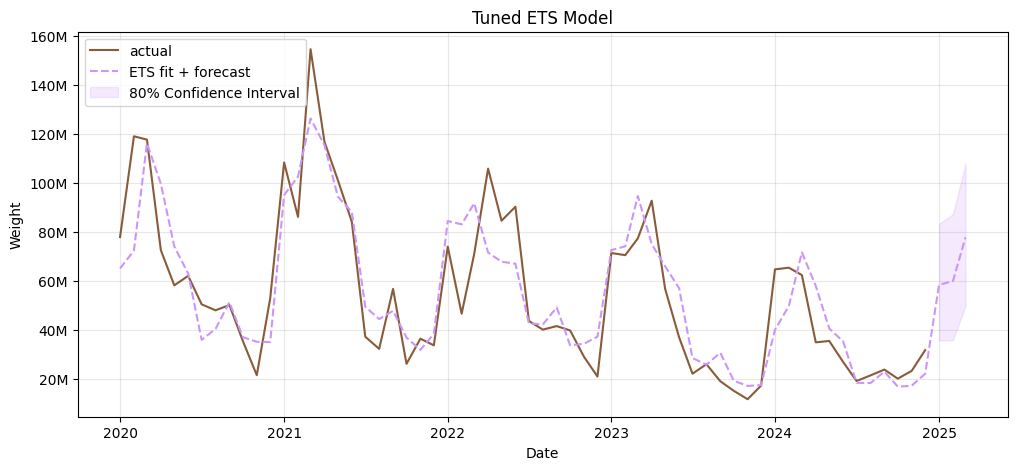

        Date  Forecast  Lower_80_CI  Upper_80_CI
0 2025-01-01  58375519     35705863     83288705
1 2025-02-01  59903522     35805129     87222407
2 2025-03-01  77773565     49838313    107859569


In [76]:
np.random.seed(42)

triple_tuned_ets = ETSModel(
    endog=data['Weight'],
    error='add',
    trend='add',
    damped_trend=True,
    seasonal='mul',
    seasonal_periods=12,
).fit(optimized=True)

fitted_ets = triple_tuned_ets.fittedvalues

forecast_steps = 3
last_date = data['Import Date'].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq='MS'
)
# e.g.,:
# start=len(data)     = 61 → 1st out-of-sample prediction
# end=len(data)+3-1   = 63 → 3rd out-of-sample prediction
pred = triple_tuned_ets.get_prediction(start=len(data), end=len(data)+forecast_steps-1)
sf = pred.summary_frame(alpha=0.1)
forecast_ets = sf['mean']
lower = sf['pi_lower']
upper = sf['pi_upper']

forecast_simple = triple_tuned_ets.forecast(steps=forecast_steps)

combined_preds_ets = np.concatenate([fitted_ets.values, forecast_simple.values])
combined_dates_ets = pd.concat([data['Import Date'], pd.Series(future_dates)], ignore_index=True)

plt.figure(figsize=(12, 5))

plt.plot(data['Import Date'], data['Weight'], color=custom_palette[2], label="actual")

plt.plot(combined_dates_ets, combined_preds_ets, color=custom_palette[0],
         linestyle='--', label="ETS fit + forecast")

plt.fill_between(future_dates, lower.values, upper.values,
                color=custom_palette[0], alpha=0.2, label='80% Confidence Interval')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))
plt.legend(loc='upper left')
plt.title("Tuned ETS Model")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(alpha=0.3)
plt.show()

forecast_table = pd.DataFrame({
    'Date': future_dates,
    'Forecast': forecast_ets.values.astype(int),
    'Lower_80_CI': lower.values.astype(int),
    'Upper_80_CI': upper.values.astype(int)
}).round(2)
print(forecast_table)


The ETS model CIs are a good gut check. Now that I can see they are very similar, I am comfortable using the bootstrapped CI values on the Triple Exponential Smoothing model, which I will use as final since the estimate and CI come from the same model.

https://www.statsmodels.org/v0.12.2/examples/notebooks/generated/ets.html#Holt-Winters'-seasonal-method

Log transformation:

Since the data is volatile, I also try out log transforming the data:

This showed no improvement over the Tuned Triple Exponential Smoothing with original data:

In [77]:
train = data['Weight'][:-5]
test = data['Weight'][-5:]

triple_tuned_log = ExponentialSmoothing(np.log1p(train),
                              trend="additive",damped_trend=True,
                              seasonal="multiplicative",
                              seasonal_periods=12).fit(optimized=True)
triple_tuned_log_preds = np.expm1(triple_tuned_log.forecast(len(test)))

In [78]:
train = data[:-5]
test = data[-5:]

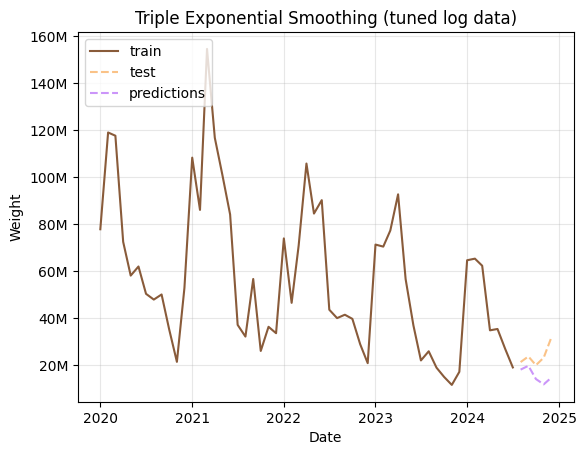

In [79]:
plt.plot(train['Import Date'], train['Weight'], color=custom_palette[2], label="train")
plt.plot(test['Import Date'], test['Weight'], color=custom_palette[1], linestyle="--", label="test")
plt.plot(test['Import Date'], triple_tuned_log_preds, color=custom_palette[0], linestyle="--", label="predictions")

def millions(x, pos):
    return f'{int(x/1e6)}M'

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

plt.legend(loc='upper left')
plt.title("Triple Exponential Smoothing (tuned log data)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(alpha=0.3)
plt.show()

In [80]:
horizon = 3
exp_ts_tuned_log_results = []

for cutoff in range(44, 60):
    if cutoff + horizon >= len(data):
        break

    train_log = np.log1p(data['Weight'].iloc[:cutoff + 1])

    triple_tuned_log = ExponentialSmoothing(
        train_log,
        trend="additive", damped_trend=True,
        seasonal="multiplicative", seasonal_periods=12
    ).fit(optimized=True)

    yhat_log = triple_tuned_log.forecast(steps=horizon)
    yhat = np.expm1(yhat_log)

    y_true = data['Weight'].iloc[cutoff + 1 : cutoff + 1 + horizon]

    for h in range(horizon):
        ae = abs(yhat.iloc[h] - y_true.iloc[h])
        ape = ae / max(abs(y_true.iloc[h]), 1e-8)

        exp_ts_tuned_log_results.append({
            'cutoff': cutoff,
            'horizon': h + 1,
            'cutoff_month': data['Import Date'].iloc[cutoff].to_period('M').to_timestamp(),
            'month': data['Import Date'].iloc[cutoff + h + 1].to_period('M').to_timestamp(),
            'y': y_true.iloc[h],
            'yhat': yhat.iloc[h],
            'AE': ae,
            'APE': ape
        })

exp_ts_tuned_log_cv_df = pd.DataFrame(exp_ts_tuned_log_results)
exp_ts_tuned_log_cv_df.style.format({
    'cutoff_month': '{:%m-%d-%Y}',
    'month': '{:%m-%d-%Y}',
    'y': '{:,.0f}',
    'yhat': '{:,.0f}',
    'AE': '{:,.0f}',
    'APE': '{:.0%}'
})

,cutoff,horizon,cutoff_month,month,y,yhat,AE,APE
0,44,1,09-01-2023,10-01-2023,"15,172,388","18,716,898","3,544,510",23%
1,44,2,09-01-2023,11-01-2023,"11,741,002","16,070,462","4,329,460",37%
2,44,3,09-01-2023,12-01-2023,"17,305,596","18,858,595","1,552,999",9%
3,45,1,10-01-2023,11-01-2023,"11,741,002","14,724,723","2,983,721",25%
4,45,2,10-01-2023,12-01-2023,"17,305,596","17,270,938","34,658",0%
5,45,3,10-01-2023,01-01-2024,"64,702,033","39,771,858","24,930,175",39%
6,46,1,11-01-2023,12-01-2023,"17,305,596","15,722,016","1,583,580",9%
7,46,2,11-01-2023,01-01-2024,"64,702,033","36,043,927","28,658,106",44%
8,46,3,11-01-2023,02-01-2024,"65,375,575","33,846,981","31,528,594",48%
9,47,1,12-01-2023,01-01-2024,"64,702,033","37,501,311","27,200,722",42%


In [81]:
exp_ts_tuned_log_cv = exp_ts_tuned_log_cv_df.groupby('horizon').agg(
    MAE=('AE', 'mean'),
    MAPE=('APE', 'mean'))

exp_ts_tuned_log_cv.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"8,454,657",24%
2,"10,832,715",30%
3,"12,301,647",33%


The performance is slightly worse than without the log transformation:

In [82]:
exp_ts_tuned_log_overall_MAE  = exp_ts_tuned_log_cv_df['AE'].mean()
exp_ts_tuned_log_overall_MAPE = exp_ts_tuned_log_cv_df['APE'].mean()

print(f"MAE: {exp_ts_tuned_log_overall_MAE:,.0f}")
print(f"MAPE (%): {exp_ts_tuned_log_overall_MAPE:.0%}")

MAE: 10,529,673
MAPE (%): 29%


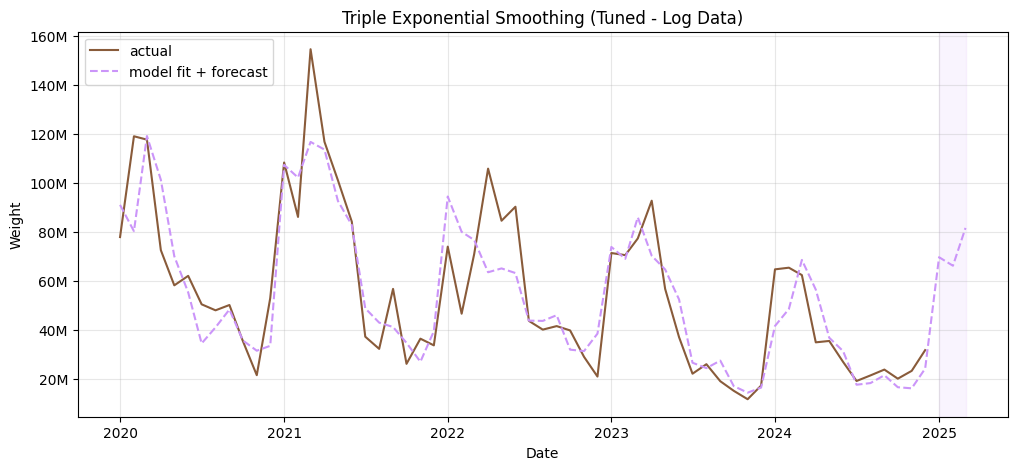

In [83]:
triple_tuned_log = ExponentialSmoothing(
    np.log1p(data['Weight']),
    trend="additive",
    damped_trend=True,
    seasonal="multiplicative",
    seasonal_periods=12
).fit(optimized=True)

fitted_log = np.expm1(triple_tuned_log.fittedvalues)

forecast_steps = 3
forecast_log = np.expm1(triple_tuned_log.forecast(steps=forecast_steps))

last_date = data['Import Date'].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq='MS'
)

combined_preds_log = np.concatenate([fitted_log.values, forecast_log.values])
combined_dates_log = pd.concat([data['Import Date'], pd.Series(future_dates)], ignore_index=True)

plt.figure(figsize=(12, 5))

plt.plot(data['Import Date'], data['Weight'], color=custom_palette[2], label="actual")

plt.plot(combined_dates_log, combined_preds_log, color=custom_palette[0], linestyle='--', label="model fit + forecast")

plt.axvspan(future_dates[0], future_dates[-1], color=custom_palette[0], alpha=0.1)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))

plt.legend(loc='upper left')
plt.title("Triple Exponential Smoothing (Tuned - Log Data)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(alpha=0.3)
plt.show()


Add CI:

In [84]:
def bootstrap_hw_intervals(model,train_values, horizon, n_boot=500):
    residuals = model.resid
    forecasts = np.zeros((n_boot, horizon))

    for i in range(n_boot):
        boot_sample = train_values + np.random.choice(residuals, size=len(train_values))
        boot_sample = np.maximum(boot_sample, 1e-6)

        boot_model = ExponentialSmoothing(
            boot_sample,
            trend="additive",
            damped_trend=True,
            seasonal="multiplicative",
            seasonal_periods=12
        ).fit(optimized=True)

        forecasts[i, :] = np.expm1(boot_model.forecast(steps=horizon))

    lower = np.percentile(forecasts, 10, axis=0)
    upper = np.percentile(forecasts, 90, axis=0)

    return pd.DataFrame({
        'horizon': range(1, horizon + 1),
        'point_forecast': np.expm1(model.forecast(steps=horizon)),
        'ci_lower': lower,
        'ci_upper': upper
    })


In [85]:
np.random.seed(42)

train_values = np.log1p(data['Weight'].values)
final_hw = ExponentialSmoothing(
    train_values,
    trend="additive", damped_trend=True,
    seasonal="multiplicative", seasonal_periods=12
).fit(optimized=True)

ci_df = bootstrap_hw_intervals(final_hw, train_values, horizon=3, n_boot=500)

In [86]:
ci_df.style.format("{:.0f}")

,horizon,point_forecast,ci_lower,ci_upper
0,1,69648864,42252005,73726939
1,2,66175582,40121510,69833090
2,3,81596184,50389126,86458491


In [87]:
future_dates = pd.date_range(
    start=data['Import Date'].iloc[-1] + pd.offsets.MonthBegin(1),
    periods=3,
    freq='MS'
)

forecast_table = pd.DataFrame({
    'Date': future_dates,
    'Forecast': ci_df['point_forecast'].round().astype(int),
    'Lower_80_CI': np.floor(ci_df['ci_lower']).astype(int),
    'Upper_80_CI': np.ceil(ci_df['ci_upper']).astype(int)
})
print(forecast_table)


        Date  Forecast  Lower_80_CI  Upper_80_CI
0 2025-01-01  69648864     42252004     73726939
1 2025-02-01  66175582     40121509     69833091
2 2025-03-01  81596184     50389125     86458492


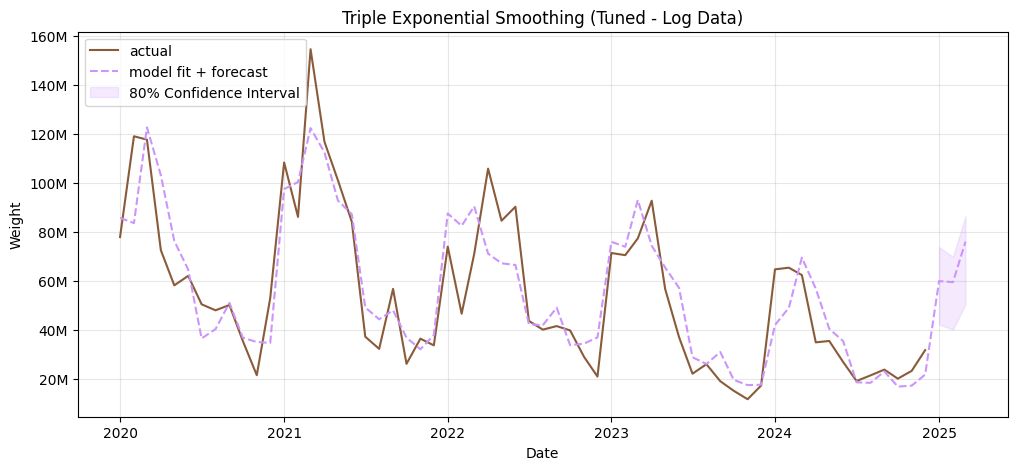

In [88]:
triple_tuned_log = ExponentialSmoothing(
    np.log1p(data['Weight']),
    trend="additive",
    damped_trend=True,
    seasonal="multiplicative",
    seasonal_periods=12
).fit(optimized=True)

fitted = np.expm1(triple_tuned_log.fittedvalues)
forecast_steps = 3
forecast = np.expm1(triple_tuned_log.forecast(steps=forecast_steps))

last_date = data['Import Date'].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq='MS'
)

combined_preds_log = np.concatenate([fitted.values, forecast.values])
combined_dates_log = pd.concat([data['Import Date'], pd.Series(future_dates)], ignore_index=True)

plt.figure(figsize=(12, 5))
plt.plot(data['Import Date'], data['Weight'], color=custom_palette[2], label="actual")
plt.plot(combined_dates, combined_preds, color=custom_palette[0], linestyle='--',
         label="model fit + forecast")

plt.fill_between(
    future_dates,
    ci_df['ci_lower'].values,
    ci_df['ci_upper'].values,
    color=custom_palette[0],
    alpha=0.2,
    label='80% Confidence Interval'
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))
plt.legend(loc='upper left')
plt.title("Triple Exponential Smoothing (Tuned - Log Data)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(alpha=0.3)
plt.show()


##Model 2: SARIMA

I next chose the SARIMA model to see if performance improved. It seemed like a good option given that the data is nonstationary and there is seasonality:

From earlier plots: (For non-log data) ACF has 1,2,12 lags and PACF has 1,12 lags

| Model          | Plot  | Observation        |
| -------------- | -------- | ------------------------ |
| **AR(p)**      | **PACF** | Cuts off after lag **p** |
| **MA(q)**      | **ACF**  | Cuts off after lag **q** |


PACF lag 1 → p = 1

ACF lag 1–2 → q = 2

Non-seasonal parameters: (p, q) = (1, 2). d in (p,d,q) will be determined from differencing below.

PACF at lag 12 → seasonal AR → P = 1

ACF at lag 12 → seasonal MA → Q = 1

There were no spikes at 24, 36 so will not consider higher orders.

Seasonal differencing D: D =1 if strong spike on ACF at lag 12.

The results (including differencing below) point to (1,1,2) (1,1,1,12) being the ideal orders for the non-log data.

In [89]:
data.head()

,Import Date,Weight
0,2020-01-01,77863938
1,2020-02-01,118967413
2,2020-03-01,117594405
3,2020-04-01,72523979
4,2020-05-01,58180114


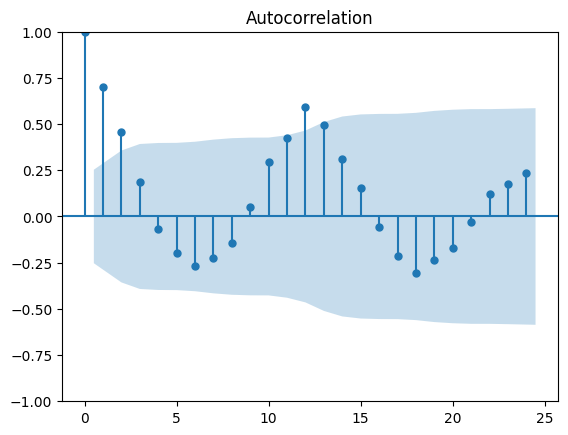

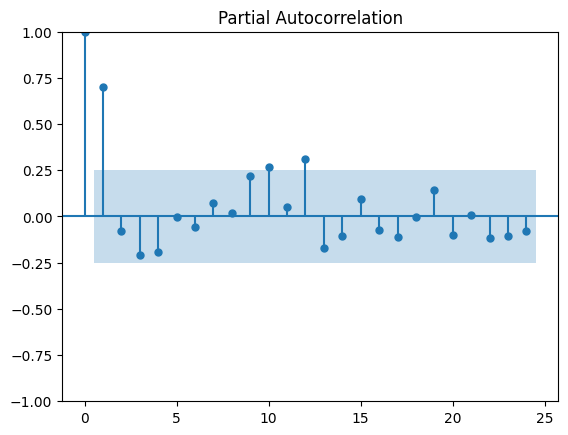

In [90]:
plot_acf(data['Weight'], lags=24)
plot_pacf(data['Weight'], lags=24)
plt.show()

In [91]:
data['y_diff'] = data['Weight'].diff()

In [92]:
diff_for_df_test = pd.DataFrame(data, columns=['Import Date','y_diff'])

In [93]:
diff_for_df_test.head()

,Import Date,y_diff
0,2020-01-01,NaN
1,2020-02-01,41103475.0
2,2020-03-01,-1373008.0
3,2020-04-01,-45070426.0
4,2020-05-01,-14343865.0


Passes Dickey Fuller Test after differencing 1 time (stationary now). Do not need to difference again. Will set d=1.

In [94]:
adf_b4, pvalue_b4, usedlag_, nobs_, critical_values_, icbest_ = adfuller(diff_for_df_test['y_diff'].dropna())

print(f"ADF: {adf_b4:.2f}")
print(f"p-value: {pvalue_b4:.8f}")

ADF: -5.83
p-value: 0.00000040


The ideal parameters appear to be (2,1,1) (1,1,1,12) for log data:

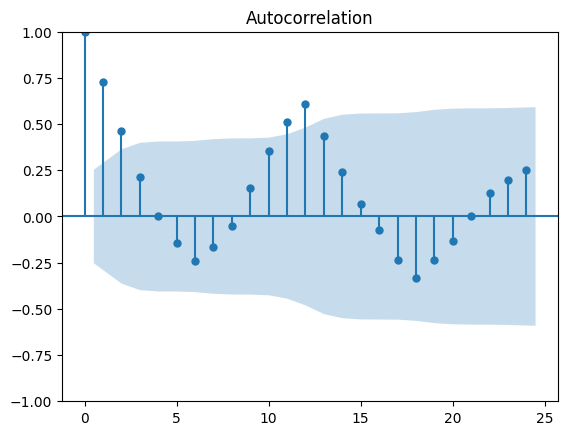

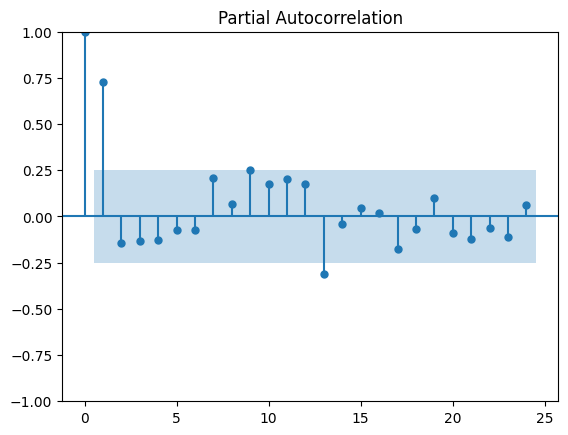

In [95]:
plot_acf(np.log1p(data['Weight']), lags=24)
plot_pacf(np.log1p(data['Weight']), lags=24)
plt.show()

Differencing with Log (to validate d=1):

In [96]:
data_log = data.copy()

In [97]:
data_log['y_diff'] = np.log1p(data_log['Weight']).diff()

In [98]:
diff_for_df_test_log = pd.DataFrame(data_log, columns=['Import Date','y_diff'])

In [99]:
diff_for_df_test_log.head()

,Import Date,y_diff
0,2020-01-01,NaN
1,2020-02-01,0.423887
2,2020-03-01,-0.011608
3,2020-04-01,-0.483324
4,2020-05-01,-0.220374


In [100]:
adf_b4, pvalue_b4, usedlag_, nobs_, critical_values_, icbest_ = adfuller(diff_for_df_test_log['y_diff'].dropna())

print(f"ADF: {adf_b4:.2f}")
print(f"p-value: {pvalue_b4:.4f}")

ADF: -3.08
p-value: 0.0282


d=1 since differencing was solved with 1 difference

Manual model with parameters from above:

In [101]:
sar_manual = sm.tsa.statespace.SARIMAX(data['Weight'],
                                order=(1,1,2),
                                seasonal_order=(1,1,1,12),
                                trend='c').fit()

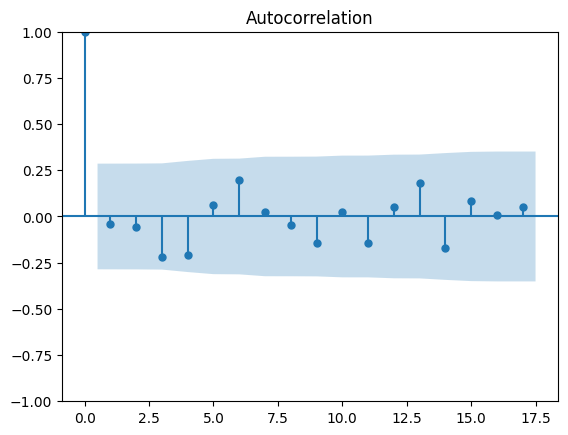

In [102]:
sm.tsa.graphics.plot_acf(sar_manual.resid[sar_manual.loglikelihood_burn:]);

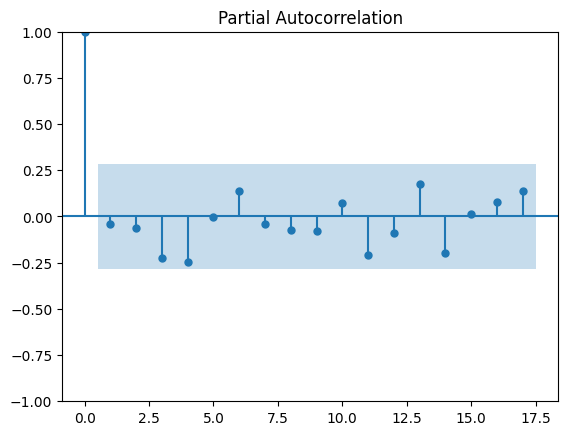

In [103]:
sm.tsa.graphics.plot_pacf(sar_manual.resid[sar_manual.loglikelihood_burn:]);

Diagnostics are pretty good: residuals look like white noise, only slight right skew on histogram of residuals, q-q plot has some deviation at the upper right, but no autocorrelation (!):

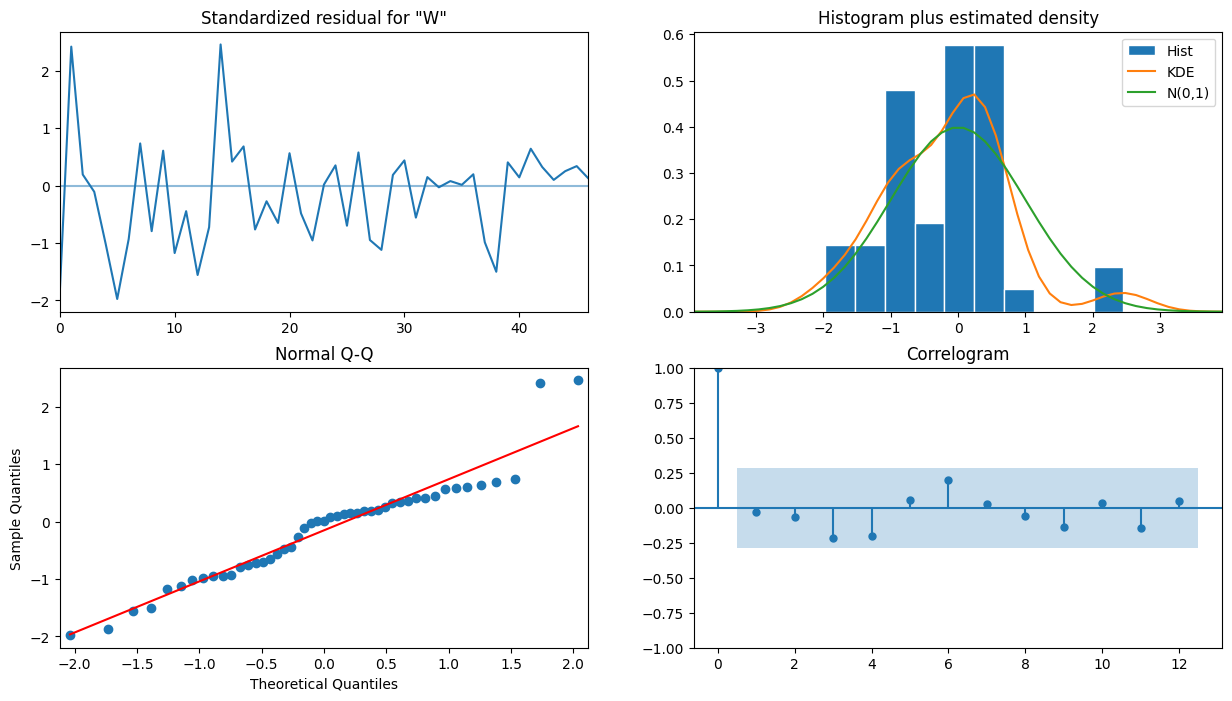

In [104]:
sar_manual.plot_diagnostics(figsize = (15,8),lags = 12);

Inputting ideal manual option (based on visuals/tests):

In [105]:
horizon = 3
manual_results = []

for cutoff in range(44, 60):
    if cutoff + horizon >= len(data):
        break

    train = data.iloc[:cutoff+1]

    sar_manual = sm.tsa.SARIMAX(
        train['Weight'],
        order=(1,1,2),
        seasonal_order=(1,1,1,12),
        trend='c',
        use_exact_diffuse=True
    ).fit(disp=False)

    yhat = sar_manual.forecast(steps=horizon)
    y_true = data['Weight'].iloc[cutoff+1: cutoff+1 + horizon]

    for h in range(horizon):
        ae = abs(yhat.iloc[h] - y_true.iloc[h])
        ape = ae / max(abs(y_true.iloc[h]), 1e-8)

        manual_results.append({
            'cutoff': cutoff,
            'horizon': h + 1,
            'cutoff_month': data['Import Date'].iloc[cutoff].to_period('M').to_timestamp(),
            'month': data['Import Date'].iloc[cutoff + h + 1].to_period('M').to_timestamp(),
            'y': y_true.iloc[h],
            'yhat': yhat.iloc[h],
            'AE': ae,
            'APE': ape
        })

sarima_manual_cv_df = pd.DataFrame(manual_results)
sarima_manual_cv_df.style.format({
    'cutoff_month': '{:%m-%d-%Y}',
    'month': '{:%m-%d-%Y}',
    'y': '{:,.0f}',
    'yhat': '{:,.0f}',
    'AE': '{:,.0f}',
    'APE': '{:.0%}'
})

,cutoff,horizon,cutoff_month,month,y,yhat,AE,APE
0,44,1,09-01-2023,10-01-2023,"15,172,388","-902,180","16,074,568",106%
1,44,2,09-01-2023,11-01-2023,"11,741,002","-7,499,335","19,240,337",164%
2,44,3,09-01-2023,12-01-2023,"17,305,596","-8,421,289","25,726,885",149%
3,45,1,10-01-2023,11-01-2023,"11,741,002","-1,016,610","12,757,612",109%
4,45,2,10-01-2023,12-01-2023,"17,305,596","-6,792,540","24,098,136",139%
5,45,3,10-01-2023,01-01-2024,"64,702,033","41,323,640","23,378,393",36%
6,46,1,11-01-2023,12-01-2023,"17,305,596","-3,223,811","20,529,407",119%
7,46,2,11-01-2023,01-01-2024,"64,702,033","40,478,792","24,223,241",37%
8,46,3,11-01-2023,02-01-2024,"65,375,575","30,235,118","35,140,457",54%
9,47,1,12-01-2023,01-01-2024,"64,702,033","55,283,347","9,418,686",15%


In [106]:
sarima_manual_cv = sarima_manual_cv_df.groupby('horizon').agg(
    MAE=('AE', 'mean'),
    MAPE=('APE', 'mean'))

sarima_manual_cv.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"16,481,080",72%
2,"23,139,193",99%
3,"27,247,696",105%


The MAPE is extremely high which is surprising, given that this was the intuitively ideal combo of parameters. However, this is on the non-log transformed data.

In [107]:
sarima_manual_overall_MAE  = sarima_manual_cv_df['AE'].mean()
sarima_manual_overall_MAPE = sarima_manual_cv_df['APE'].mean()

print(f"MAE: {sarima_manual_overall_MAE:,.0f}")
print(f"MAPE (%): {sarima_manual_overall_MAPE:.0%}")

MAE: 22,289,323
MAPE (%): 92%


Run Auto-ARIMA to either verify selected parameters or identify more optimal ones:

This "auto" option iterates through options, but with safeguards to min/max parameters based on previous decomposition/visuals/tests:

Forcing d and D to be 1 and letting the rest run:

In [108]:
sarima_auto_model = pm.auto_arima(data['Weight'],
                          start_p=0,
                          d=1,
                          start_q=0,
                          max_p=5,
                          max_d=1,
                          max_q=5,
                          start_P=0,
                          D=1,
                          start_Q=0,
                          max_P=2,
                          max_D=1,
                          max_Q=2,
                          max_order=5,
                          m=12,
                          seasonal=True,
                          stepwise=False,
                          suppress_warnings=True,
                          error_action='trace',
                          trace=True,
                          random_state=42
                          )

 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1739.523, Time=0.02 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=inf, Time=0.09 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=1727.007, Time=0.18 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=1738.266, Time=0.05 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=0.17 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=1727.890, Time=0.30 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1736.318, Time=0.19 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=1714.992, Time=0.33 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=1727.517, Time=0.40 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1735.337, Time=0.03 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1721.028, Time=0.11 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=1720.941, Time=0.29 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1733.606, Time=0.07 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1722.198, Time=0.16 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=1721.538, Time=0.34 sec
 ARIM

Best model parameters:

In [109]:
print('order: ',sarima_auto_model.order)
print('seasonal order: ',sarima_auto_model.seasonal_order)

order:  (0, 1, 0)
seasonal order:  (2, 1, 1, 12)


In [110]:
horizon = 3
auto_results = []

for cutoff in range(44, 60):
    if cutoff + horizon >= len(data):
        break

    train = data.iloc[:cutoff+1]

    sar_auto = sm.tsa.SARIMAX(
        train['Weight'],
        order=sarima_auto_model.order,
        seasonal_order=sarima_auto_model.seasonal_order,
        trend='c',
        use_exact_diffuse=True
    ).fit(disp=False)

    yhat = sar_auto.forecast(steps=horizon)
    y_true = data['Weight'].iloc[cutoff+1: cutoff+1 + horizon]

    for h in range(horizon):
        ae = abs(yhat.iloc[h] - y_true.iloc[h])
        ape = ae / max(abs(y_true.iloc[h]), 1e-8)

        auto_results.append({
            'cutoff': cutoff,
            'horizon': h + 1,
            'cutoff_month': data['Import Date'].iloc[cutoff].to_period('M').to_timestamp(),
            'month': data['Import Date'].iloc[cutoff + h + 1].to_period('M').to_timestamp(),
            'y': y_true.iloc[h],
            'yhat': yhat.iloc[h],
            'AE': ae,
            'APE': ape
        })

sarima_auto_cv_df = pd.DataFrame(auto_results)
sarima_auto_cv_df.style.format({
    'cutoff_month': '{:%m-%d-%Y}',
    'month': '{:%m-%d-%Y}',
    'y': '{:,.0f}',
    'yhat': '{:,.0f}',
    'AE': '{:,.0f}',
    'APE': '{:.0%}'
})

,cutoff,horizon,cutoff_month,month,y,yhat,AE,APE
0,44,1,09-01-2023,10-01-2023,"15,172,388","11,503,517","3,668,871",24%
1,44,2,09-01-2023,11-01-2023,"11,741,002","-2,527,554","14,268,556",122%
2,44,3,09-01-2023,12-01-2023,"17,305,596","2,118,017","15,187,579",88%
3,45,1,10-01-2023,11-01-2023,"11,741,002","742,295","10,998,707",94%
4,45,2,10-01-2023,12-01-2023,"17,305,596","5,909,236","11,396,360",66%
5,45,3,10-01-2023,01-01-2024,"64,702,033","56,883,290","7,818,743",12%
6,46,1,11-01-2023,12-01-2023,"17,305,596","17,279,016","26,580",0%
7,46,2,11-01-2023,01-01-2024,"64,702,033","68,340,220","3,638,187",6%
8,46,3,11-01-2023,02-01-2024,"65,375,575","58,497,641","6,877,934",11%
9,47,1,12-01-2023,01-01-2024,"64,702,033","68,868,793","4,166,760",6%


In [111]:
sarima_auto_cv = sarima_auto_cv_df.groupby('horizon').agg(
    MAE=('AE', 'mean'),
    MAPE=('APE', 'mean'))

sarima_auto_cv.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"11,563,515",40%
2,"18,363,968",72%
3,"22,950,214",88%


The MAPE sees improvement with this model:

In [112]:
sarima_auto_overall_MAE  = sarima_auto_cv_df['AE'].mean()
sarima_auto_overall_MAPE = sarima_auto_cv_df['APE'].mean()

print(f"MAE: {sarima_auto_overall_MAE:,.0f}")
print(f"MAPE (%): {sarima_auto_overall_MAPE:.0%}")

MAE: 17,625,899
MAPE (%): 67%


This shows that a simpler non-seasonal  component (0,1,0) and a stronger seasonal component (2,1,1,12) fit the data better because seasonality dictates the pattern the most.

Flex full search:

Does not set any values except 12 month seasonality (including no setting for d or D), so it is a very flexible, wide grid search:

In [113]:
sarima_flex_full_auto_model = pm.auto_arima(data['Weight'], start_p=0, start_q=0,
                           max_p=5, max_q=5, m=12,
                           start_P=0, seasonal=True,
                           trace=True,
                           error_action='trace',
                           suppress_warnings=True,
                           stepwise=False)

 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2177.775, Time=0.01 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=2165.766, Time=0.06 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=2167.578, Time=0.12 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=2165.753, Time=0.04 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=2167.895, Time=0.09 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=2168.258, Time=0.31 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=2167.717, Time=0.09 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=2169.315, Time=0.21 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : AIC=2169.717, Time=0.37 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=2179.894, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2166.436, Time=0.06 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=2168.188, Time=0.14 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=2166.356, Time=0.05 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=2168.056, Time=0.20 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=2168.931, Time=0.54

In [114]:
print('order: ',sarima_flex_full_auto_model.order)
print('seasonal order: ',sarima_flex_full_auto_model.seasonal_order)

order:  (0, 1, 3)
seasonal order:  (0, 0, 1, 12)


In [115]:
horizon = 3
flex_full_results = []

for cutoff in range(44, 60):
    if cutoff + horizon >= len(data):
        break

    train = data.iloc[:cutoff+1]

    sar_flex_full = sm.tsa.SARIMAX(
        train['Weight'],
        order=sarima_flex_full_auto_model.order,
        seasonal_order=sarima_flex_full_auto_model.seasonal_order,
        trend='c',
        use_exact_diffuse=True
    ).fit(disp=False)

    yhat = sar_flex_full.forecast(steps=horizon)
    y_true = data['Weight'].iloc[cutoff+1: cutoff+1 + horizon]

    for h in range(horizon):
        ae = abs(yhat.iloc[h] - y_true.iloc[h])
        ape = ae / max(abs(y_true.iloc[h]), 1e-8)

        flex_full_results.append({
            'cutoff': cutoff,
            'horizon': h + 1,
            'cutoff_month': data['Import Date'].iloc[cutoff].to_period('M').to_timestamp(),
            'month': data['Import Date'].iloc[cutoff + h + 1].to_period('M').to_timestamp(),
            'y': y_true.iloc[h],
            'yhat': yhat.iloc[h],
            'AE': ae,
            'APE': ape
        })

sarima_flex_full_cv_df = pd.DataFrame(flex_full_results)
sarima_flex_full_cv_df.style.format({
    'cutoff_month': '{:%m-%d-%Y}',
    'month': '{:%m-%d-%Y}',
    'y': '{:,.0f}',
    'yhat': '{:,.0f}',
    'AE': '{:,.0f}',
    'APE': '{:.0%}'
})

,cutoff,horizon,cutoff_month,month,y,yhat,AE,APE
0,44,1,09-01-2023,10-01-2023,"15,172,388","32,338,681","17,166,293",113%
1,44,2,09-01-2023,11-01-2023,"11,741,002","25,880,186","14,139,184",120%
2,44,3,09-01-2023,12-01-2023,"17,305,596","29,161,960","11,856,364",69%
3,45,1,10-01-2023,11-01-2023,"11,741,002","16,121,887","4,380,885",37%
4,45,2,10-01-2023,12-01-2023,"17,305,596","20,459,783","3,154,187",18%
5,45,3,10-01-2023,01-01-2024,"64,702,033","46,031,411","18,670,622",29%
6,46,1,11-01-2023,12-01-2023,"17,305,596","17,513,162","207,566",1%
7,46,2,11-01-2023,01-01-2024,"64,702,033","43,713,798","20,988,235",32%
8,46,3,11-01-2023,02-01-2024,"65,375,575","46,084,618","19,290,957",30%
9,47,1,12-01-2023,01-01-2024,"64,702,033","44,154,691","20,547,342",32%


In [116]:
sarima_flex_full_cv = sarima_flex_full_cv_df.groupby('horizon').agg(
    MAE=('AE', 'mean'),
    MAPE=('APE', 'mean'))

sarima_flex_full_cv.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"8,015,458",29%
2,"10,640,699",37%
3,"10,874,315",33%


The performance significantly improves with the fully flexible auto arima grid search. This is almost as good as the best Triple Exponential Smoothing model earlier that had 27% MAPE:

In [117]:
sarima_flex_full_overall_MAE  = sarima_flex_full_cv_df['AE'].mean()
sarima_flex_full_overall_MAPE = sarima_flex_full_cv_df['APE'].mean()

print(f"MAE: {sarima_flex_full_overall_MAE:,.0f}")
print(f"MAPE (%): {sarima_flex_full_overall_MAPE:.0%}")

MAE: 9,843,491
MAPE (%): 33%


Again, I will also try a log transformation on the data and refit the models. First I look at the decomposition again with the log transformed data, and it does not look different, so my intuitively ideal manual version should not be different for d and m (will have other differences based on the autocorrelation):

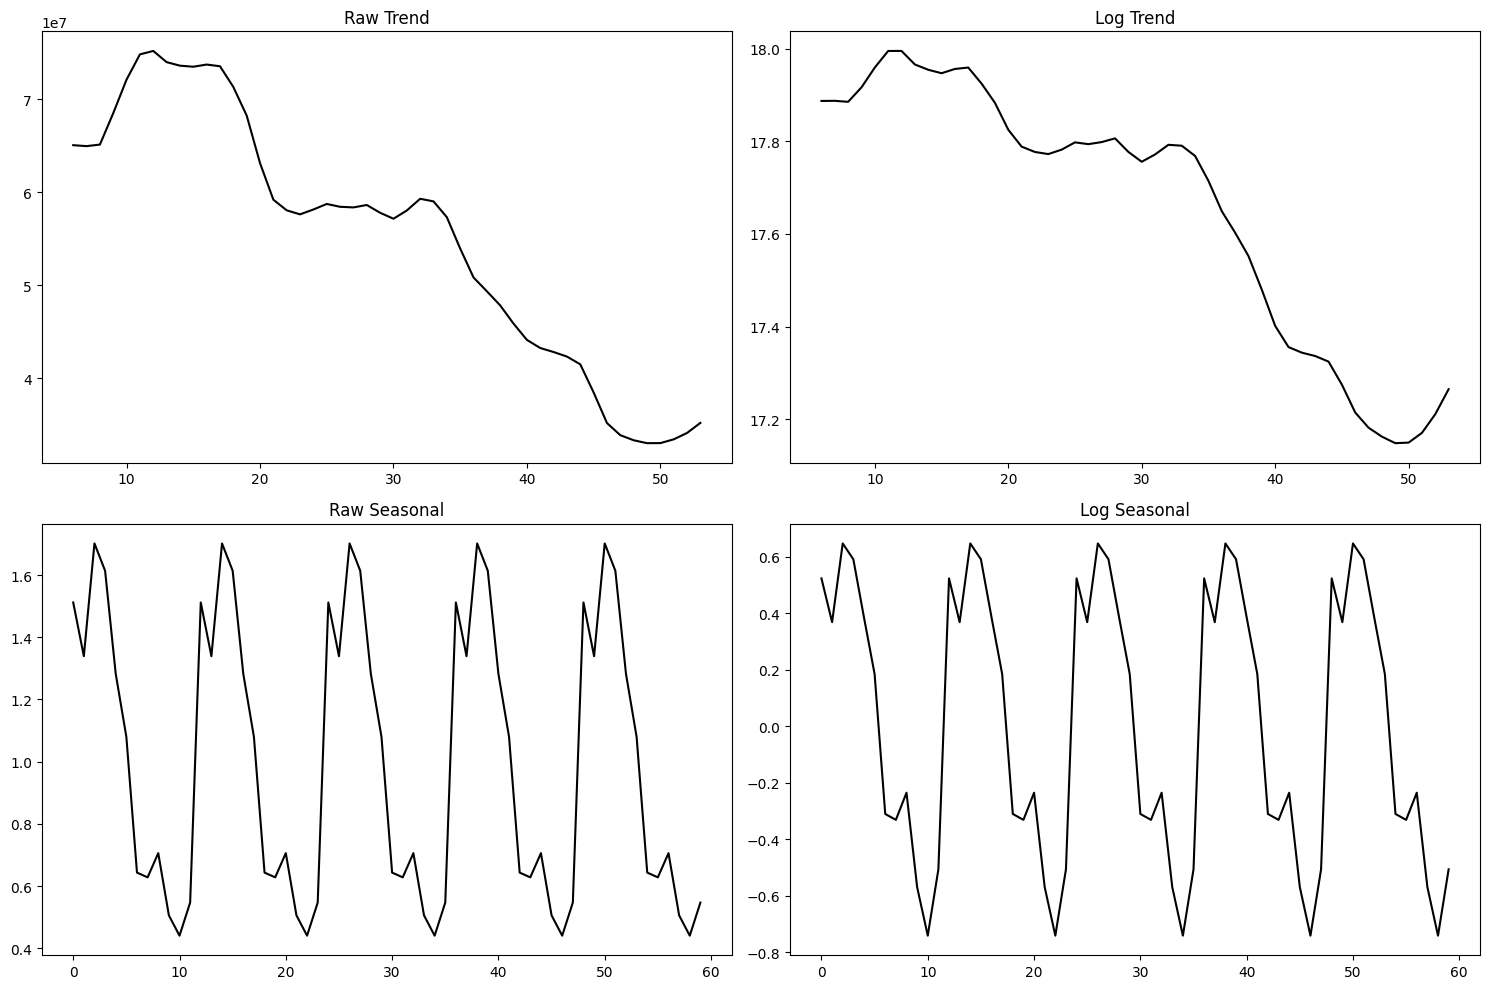

In [118]:
decomp_raw = seasonal_decompose(data['Weight'], model='multiplicative', period=12)

data['Weight_log'] = np.log1p(data['Weight'])
decomp_log = seasonal_decompose(data['Weight_log'], model='additive', period=12)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

decomp_raw.trend.plot(ax=axes[0,0], color='black'); axes[0,0].set_title('Raw Trend')
decomp_log.trend.plot(ax=axes[0,1], color='black'); axes[0,1].set_title('Log Trend')
decomp_raw.seasonal.plot(ax=axes[1,0], color='black'); axes[1,0].set_title('Raw Seasonal')
decomp_log.seasonal.plot(ax=axes[1,1], color='black'); axes[1,1].set_title('Log Seasonal')

plt.tight_layout()
plt.show()


Run auto arima on log data (but set d's to have some boundaries based on observation of the data):

In [119]:
sarima_log_auto = pm.auto_arima(np.log1p(data['Weight']),
                           start_p=0, start_q=0,
                           max_p=5, max_q=5, m=12,
                           start_P=0, seasonal=True,
                           d=1, D=1,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=False)

 ARIMA(0,1,0)(0,1,0)[12]             : AIC=53.203, Time=0.03 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=inf, Time=0.21 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=inf, Time=0.50 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=53.361, Time=0.06 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=0.66 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=inf, Time=2.90 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=42.788, Time=0.22 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=0.96 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=42.631, Time=0.85 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=49.652, Time=0.03 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.32 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=inf, Time=0.79 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=49.971, Time=0.10 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=inf, Time=0.72 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=1.36 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=41.387, T

In [120]:
print('order: ',sarima_log_auto.order)
print('seasonal order: ',sarima_log_auto.seasonal_order)

order:  (0, 1, 1)
seasonal order:  (2, 1, 2, 12)


In [121]:
horizon = 3
log_auto_results = []

for cutoff in range(44, 60):
    if cutoff + horizon >= len(data):
        break

    train = data.iloc[:cutoff+1]

    sarima_log_auto_model = sm.tsa.SARIMAX(
        np.log1p(train['Weight']),
        order=sarima_log_auto.order,
        seasonal_order=sarima_log_auto.seasonal_order,
        trend='c',
        use_exact_diffuse=True
    ).fit(disp=False)

    yhat = np.expm1(sarima_log_auto_model.forecast(steps=horizon))
    y_true = data['Weight'].iloc[cutoff+1: cutoff+1 + horizon]

    for h in range(horizon):
        ae = abs(yhat.iloc[h] - y_true.iloc[h])
        ape = ae / max(abs(y_true.iloc[h]), 1e-8)

        log_auto_results.append({
            'cutoff': cutoff,
            'horizon': h + 1,
            'cutoff_month': data['Import Date'].iloc[cutoff].to_period('M').to_timestamp(),
            'month': data['Import Date'].iloc[cutoff + h + 1].to_period('M').to_timestamp(),
            'y': y_true.iloc[h],
            'yhat': yhat.iloc[h],
            'AE': ae,
            'APE': ape
        })

sarima_log_auto_cv_df = pd.DataFrame(log_auto_results)
sarima_log_auto_cv_df.style.format({
    'cutoff_month': '{:%m-%d-%Y}',
    'month': '{:%m-%d-%Y}',
    'y': '{:,.0f}',
    'yhat': '{:,.0f}',
    'AE': '{:,.0f}',
    'APE': '{:.0%}'
})

,cutoff,horizon,cutoff_month,month,y,yhat,AE,APE
0,44,1,09-01-2023,10-01-2023,"15,172,388","18,132,359","2,959,971",20%
1,44,2,09-01-2023,11-01-2023,"11,741,002","11,188,104","552,898",5%
2,44,3,09-01-2023,12-01-2023,"17,305,596","15,839,031","1,466,565",8%
3,45,1,10-01-2023,11-01-2023,"11,741,002","10,024,694","1,716,308",15%
4,45,2,10-01-2023,12-01-2023,"17,305,596","14,694,612","2,610,984",15%
5,45,3,10-01-2023,01-01-2024,"64,702,033","33,970,825","30,731,208",47%
6,46,1,11-01-2023,12-01-2023,"17,305,596","16,423,567","882,029",5%
7,46,2,11-01-2023,01-01-2024,"64,702,033","37,164,728","27,537,305",43%
8,46,3,11-01-2023,02-01-2024,"65,375,575","32,163,380","33,212,195",51%
9,47,1,12-01-2023,01-01-2024,"64,702,033","38,181,643","26,520,390",41%


In [122]:
sarima_log_auto_cv = sarima_log_auto_cv_df.groupby('horizon').agg(
    MAE=('AE', 'mean'),
    MAPE=('APE', 'mean'))

sarima_log_auto_cv.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"8,183,549",22%
2,"9,969,859",27%
3,"11,474,863",31%


Performance improved significantly to the same overall MAPE as the best performing Triple Exponential Smoothing model from earlier:

In [123]:
sarima_log_auto_overall_MAE  = sarima_log_auto_cv_df['AE'].mean()
sarima_log_auto_overall_MAPE = sarima_log_auto_cv_df['APE'].mean()

print(f"MAE: {sarima_log_auto_overall_MAE:,.0f}")
print(f"MAPE: {sarima_log_auto_overall_MAPE:.0%}")

MAE: 9,876,090
MAPE: 27%


Full flexible auto arima - not setting anything (not setting d's):

In [124]:
sarima_log_full_flex = pm.auto_arima(np.log1p(data['Weight']),
                           start_p=0, start_q=0,
                           max_p=5, max_q=5, m=12,
                           start_P=0, seasonal=True,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=False)

 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=74.720, Time=0.03 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=58.069, Time=0.10 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=60.069, Time=0.34 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=59.645, Time=0.08 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=61.620, Time=0.25 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=1.92 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=76.596, Time=0.63 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=59.177, Time=0.27 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=61.165, Time=0.75 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=59.840, Time=0.17 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.03 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=

In [125]:
print('order: ',sarima_log_full_flex.order)
print('seasonal order: ',sarima_log_full_flex.seasonal_order)

order:  (1, 1, 1)
seasonal order:  (1, 0, 1, 12)


In [126]:
horizon = 3
log_full_flex_results = []

for cutoff in range(44, 60):
    if cutoff + horizon >= len(data):
        break

    train = data.iloc[:cutoff+1]

    sarima_log_full_flex_model = sm.tsa.SARIMAX(
        np.log1p(train['Weight']),
        order=sarima_log_full_flex.order,
        seasonal_order=sarima_log_full_flex.seasonal_order,
        trend='c',
        use_exact_diffuse=True
    ).fit(disp=False)

    yhat = np.expm1(sarima_log_full_flex_model.forecast(steps=horizon))
    y_true = data['Weight'].iloc[cutoff+1: cutoff+1 + horizon]

    for h in range(horizon):
        ae = abs(yhat.iloc[h] - y_true.iloc[h])
        ape = ae / max(abs(y_true.iloc[h]), 1e-8)

        log_full_flex_results.append({
            'cutoff': cutoff,
            'horizon': h + 1,
            'cutoff_month': data['Import Date'].iloc[cutoff].to_period('M').to_timestamp(),
            'month': data['Import Date'].iloc[cutoff + h + 1].to_period('M').to_timestamp(),
            'y': y_true.iloc[h],
            'yhat': yhat.iloc[h],
            'AE': ae,
            'APE': ape
        })

sarima_log_full_flex_cv_df = pd.DataFrame(log_full_flex_results)
sarima_log_full_flex_cv_df.style.format({
    'cutoff_month': '{:%m-%d-%Y}',
    'month': '{:%m-%d-%Y}',
    'y': '{:,.0f}',
    'yhat': '{:,.0f}',
    'AE': '{:,.0f}',
    'APE': '{:.0%}'
})

,cutoff,horizon,cutoff_month,month,y,yhat,AE,APE
0,44,1,09-01-2023,10-01-2023,"15,172,388","20,061,564","4,889,176",32%
1,44,2,09-01-2023,11-01-2023,"11,741,002","20,776,561","9,035,559",77%
2,44,3,09-01-2023,12-01-2023,"17,305,596","24,355,638","7,050,042",41%
3,45,1,10-01-2023,11-01-2023,"11,741,002","17,700,682","5,959,680",51%
4,45,2,10-01-2023,12-01-2023,"17,305,596","22,188,589","4,882,993",28%
5,45,3,10-01-2023,01-01-2024,"64,702,033","44,379,970","20,322,063",31%
6,46,1,11-01-2023,12-01-2023,"17,305,596","16,926,430","379,166",2%
7,46,2,11-01-2023,01-01-2024,"64,702,033","38,521,759","26,180,274",40%
8,46,3,11-01-2023,02-01-2024,"65,375,575","38,920,467","26,455,108",40%
9,47,1,12-01-2023,01-01-2024,"64,702,033","37,479,456","27,222,577",42%


In [127]:
sarima_log_full_flex_cv = sarima_log_full_flex_cv_df.groupby('horizon').agg(
    MAE=('AE', 'mean'),
    MAPE=('APE', 'mean'))

sarima_log_full_flex_cv.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"7,851,162",23%
2,"10,110,756",31%
3,"11,697,541",32%


Performance is slightly worse with the fully flexible grid search:

In [128]:
sarima_log_full_flex_overall_MAE  = sarima_log_full_flex_cv_df['AE'].mean()
sarima_log_full_flex_overall_MAPE = sarima_log_full_flex_cv_df['APE'].mean()

print(f"MAE: {sarima_log_full_flex_overall_MAE:,.0f}")
print(f"MAPE (%): {sarima_log_full_flex_overall_MAPE:.0%}")

MAE: 9,886,487
MAPE (%): 29%


Switch to manual model:

Ideal with log (based on autocorrelation plots earlier + decomposition):

In [129]:
sarima_log_manual_order = (2,1,1)
sarima_log_manual_seasonal_order = (1,1,1,12)

In [130]:
horizon = 3
log_manual_results = []

for cutoff in range(44, 60):
    if cutoff + horizon >= len(data):
        break

    train = data.iloc[:cutoff+1]

    sarima_log_manual_model = sm.tsa.SARIMAX(
        np.log1p(train['Weight']),
        order=sarima_log_manual_order,
        seasonal_order=sarima_log_manual_seasonal_order,
        trend='c',
        use_exact_diffuse=True
    ).fit(disp=False)

    yhat = np.expm1(sarima_log_manual_model.forecast(steps=horizon))
    y_true = data['Weight'].iloc[cutoff+1: cutoff+1 + horizon]

    for h in range(horizon):
        ae = abs(yhat.iloc[h] - y_true.iloc[h])
        ape = ae / max(abs(y_true.iloc[h]), 1e-8)

        log_manual_results.append({
            'cutoff': cutoff,
            'horizon': h + 1,
            'cutoff_month': data['Import Date'].iloc[cutoff].to_period('M').to_timestamp(),
            'month': data['Import Date'].iloc[cutoff + h + 1].to_period('M').to_timestamp(),
            'y': y_true.iloc[h],
            'yhat': yhat.iloc[h],
            'AE': ae,
            'APE': ape

        })

sarima_log_manual_cv_df = pd.DataFrame(log_manual_results)
sarima_log_manual_cv_df.style.format({
    'cutoff_month': '{:%m-%d-%Y}',
    'month': '{:%m-%d-%Y}',
    'y': '{:,.0f}',
    'yhat': '{:,.0f}',
    'AE': '{:,.0f}',
    'APE': '{:.0%}'
})

,cutoff,horizon,cutoff_month,month,y,yhat,AE,APE
0,44,1,09-01-2023,10-01-2023,"15,172,388","17,532,629","2,360,241",16%
1,44,2,09-01-2023,11-01-2023,"11,741,002","14,875,542","3,134,540",27%
2,44,3,09-01-2023,12-01-2023,"17,305,596","15,783,950","1,521,646",9%
3,45,1,10-01-2023,11-01-2023,"11,741,002","14,102,240","2,361,238",20%
4,45,2,10-01-2023,12-01-2023,"17,305,596","15,695,070","1,610,526",9%
5,45,3,10-01-2023,01-01-2024,"64,702,033","38,782,126","25,919,907",40%
6,46,1,11-01-2023,12-01-2023,"17,305,596","14,413,344","2,892,252",17%
7,46,2,11-01-2023,01-01-2024,"64,702,033","37,130,369","27,571,664",43%
8,46,3,11-01-2023,02-01-2024,"65,375,575","33,732,959","31,642,616",48%
9,47,1,12-01-2023,01-01-2024,"64,702,033","39,630,166","25,071,867",39%


In [131]:
sarima_log_manual_cv = sarima_log_manual_cv_df.groupby('horizon').agg(
    MAE=('AE', 'mean'),
    MAPE=('APE', 'mean'))

sarima_log_manual_cv.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"8,358,623",24%
2,"10,539,407",30%
3,"11,917,611",33%


Performance is still looking better, although still higher than the 27% from other models:

In [132]:
sarima_log_manual_overall_MAE  = sarima_log_manual_cv_df['AE'].mean()
sarima_log_manual_overall_MAPE = sarima_log_manual_cv_df['APE'].mean()

print(f"MAE: {sarima_log_manual_overall_MAE:,.0f}")
print(f"MAPE (%): {sarima_log_manual_overall_MAPE:.0%}")

MAE: 10,271,880
MAPE (%): 29%


Below I assign the best performing model to have a "final" SARIMA model that performed the best, which was the short grid search ("auto" model) with the log-transformed data:

In [133]:
final_order = sarima_log_auto_model.model.order
final_seasonal_order = sarima_log_auto_model.model.seasonal_order

In [134]:
print(final_order)
print(final_seasonal_order)

(0, 1, 1)
(2, 1, 2, 12)


In [135]:
sarima_final_cv = sarima_log_auto_cv

In [136]:
sarima_final_cv.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"8,183,549",22%
2,"9,969,859",27%
3,"11,474,863",31%


In [137]:
sarima_final_overall_MAE = sarima_log_auto_overall_MAE
sarima_final_overall_MAPE = sarima_log_auto_overall_MAPE

In [138]:
print(f"MAE: {sarima_final_overall_MAE:,.0f}")
print(f"MAPE (%): {sarima_final_overall_MAPE:.0%}")

MAE: 9,876,090
MAPE (%): 27%


Final SARIMA plot:

(Note, removed outliers that were created from log transformation, as they skewed the view of the plot)

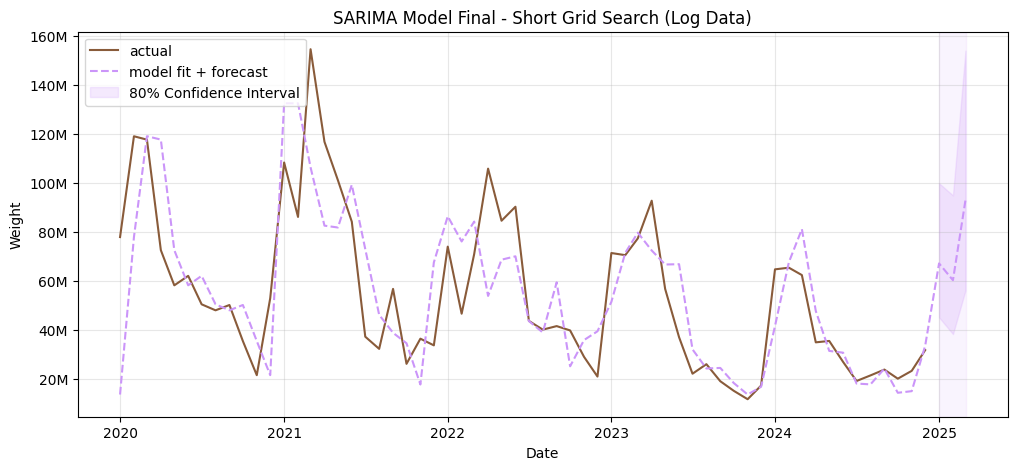

In [139]:
sar_final = sm.tsa.SARIMAX(
    np.log1p(data['Weight']),
    order=final_order,
    seasonal_order=final_seasonal_order,
    trend='c',
    use_exact_diffuse=True
).fit(disp=False)

fitted_sar_final_log = sar_final.fittedvalues

log_min, log_max = np.percentile(np.log1p(data['Weight']), [1, 99])
fitted_sar_final_log = np.clip(fitted_sar_final_log, log_min, log_max)
fitted_sar_final = np.expm1(fitted_sar_final_log)

fitted_dates = data['Import Date'].iloc[-len(fitted_sar_final):].reset_index(drop=True)

forecast_steps = 3
forecast_obj = sar_final.get_forecast(steps=forecast_steps)
forecast_mean_log = forecast_obj.predicted_mean
forecast_mean = np.expm1(forecast_mean_log)
conf_int_log = forecast_obj.conf_int(alpha=0.1)
lower = np.expm1(conf_int_log.iloc[:, 0])
upper = np.expm1(conf_int_log.iloc[:, 1])

last_date = data['Import Date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=forecast_steps, freq='MS')

combined_preds_sar_final = np.concatenate([fitted_sar_final.values, forecast_mean.values])
combined_dates_sar_final = pd.concat([fitted_dates, pd.Series(future_dates)], ignore_index=True)

plt.figure(figsize=(12, 5))
plt.plot(data['Import Date'], data['Weight'], color=custom_palette[2], label="actual")
plt.plot(combined_dates_sar_final, combined_preds_sar_final, color=custom_palette[0], linestyle='--', label="model fit + forecast")
plt.fill_between(future_dates, lower, upper, color=custom_palette[0], alpha=0.2, label='80% Confidence Interval')
plt.axvspan(future_dates[0], future_dates[-1], color=custom_palette[0], alpha=0.1)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))
plt.legend(loc='upper left')
plt.title("SARIMA Model Final - Short Grid Search (Log Data)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(alpha=0.3)
plt.show()


Model has good diagnostics now:

Diagnostics look better: white noise for residuals but histogram looks more normal, Q-Q plot looks more in-line, no autocorrelation:

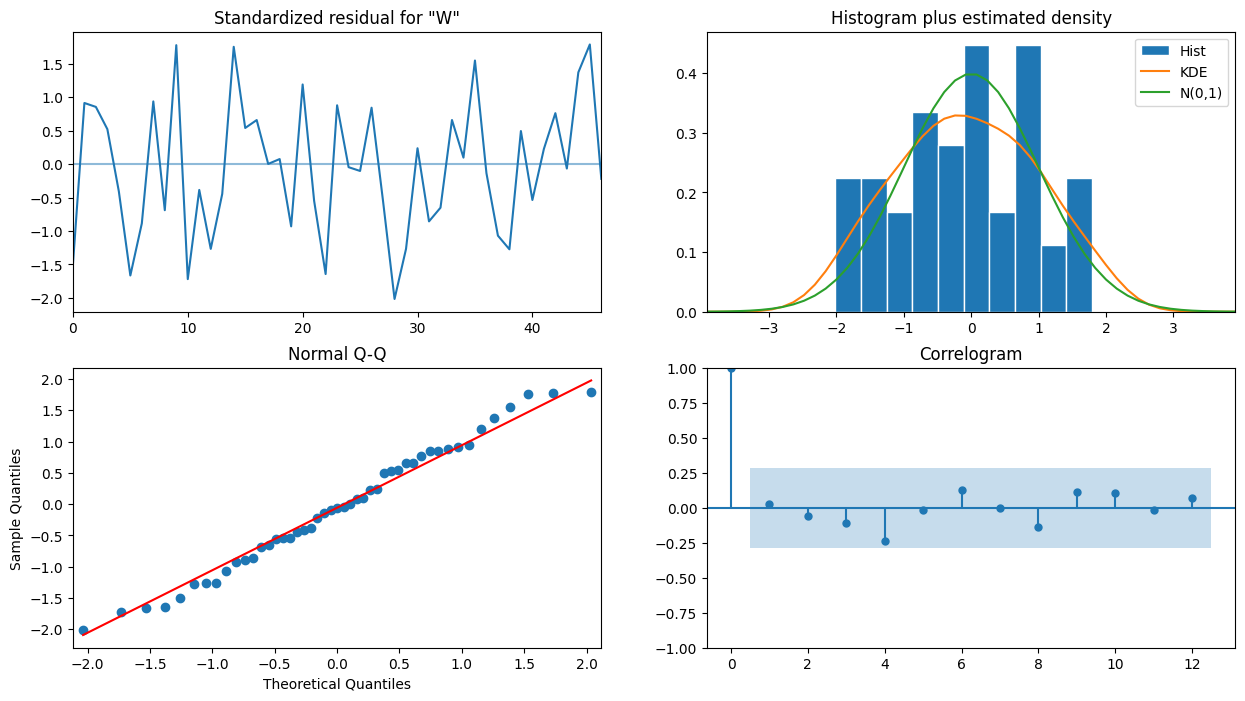

In [140]:
sar_final.plot_diagnostics(figsize = (15,8),lags = 12);

Also checking further out lags (13-24) but see no autocorrelation:

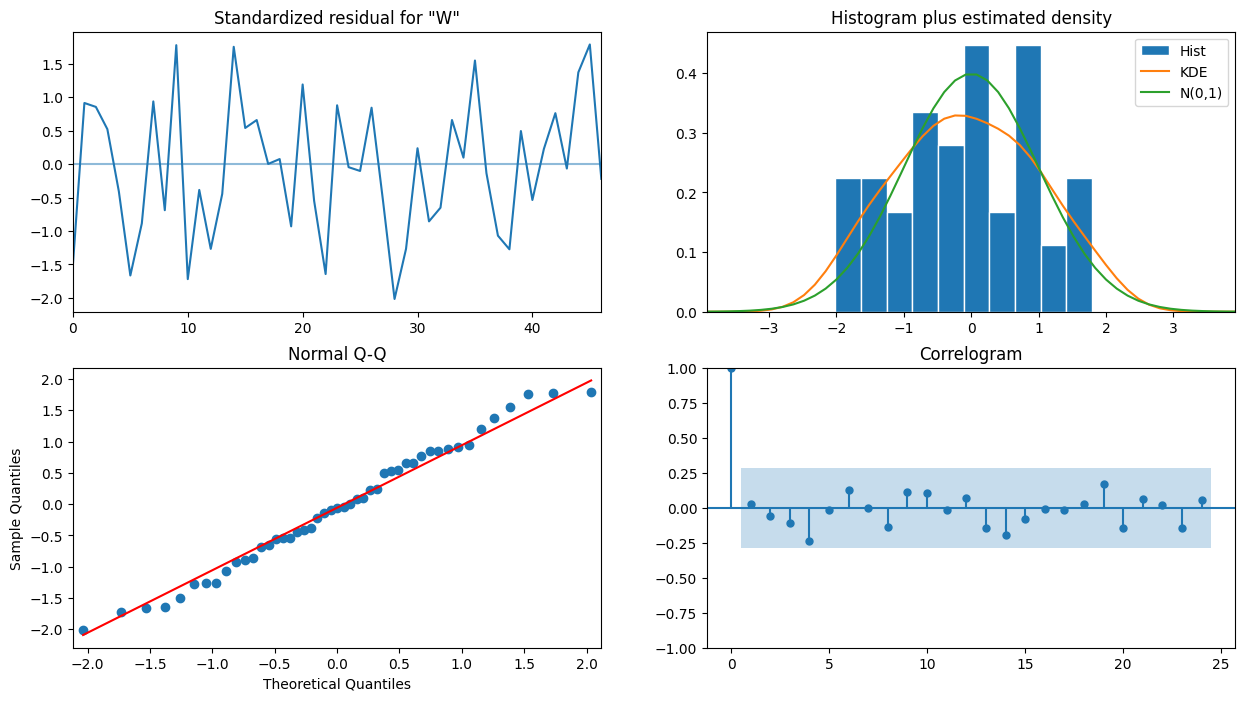

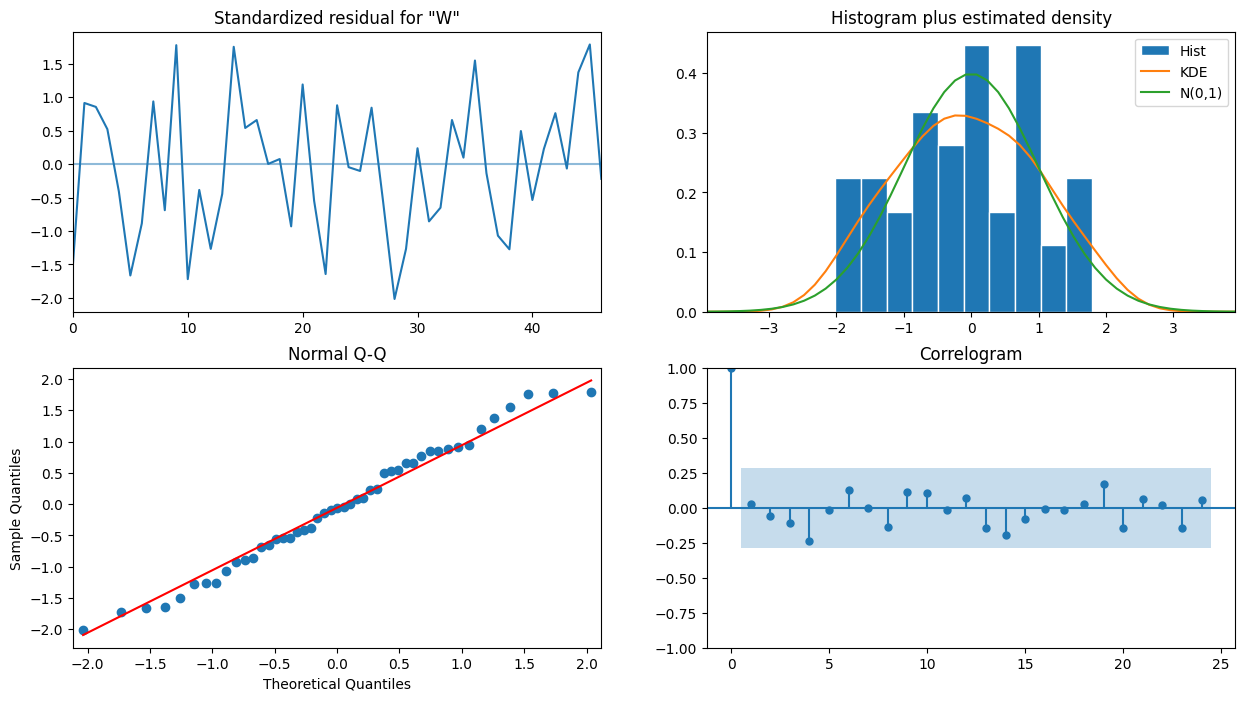

In [141]:
sar_final.plot_diagnostics(figsize=(15,8), lags=24)

In [142]:
sar_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                  Weight   No. Observations:                   60
Model:             SARIMAX(0, 1, 1)x(2, 1, [1, 2], 12)   Log Likelihood                 -26.152
Date:                                 Fri, 09 Jan 2026   AIC                             92.304
Time:                                         21:11:56   BIC                            134.190
Sample:                                              0   HQIC                           108.688
                                                  - 60                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0003      0.024      0.014      0.989      -0.046       0.047
ma.L1         -0.3927      0.174     -2.261      0.024      -0.733      -0.052
ar.S.L12       0.0558      0.491      0.114      0.909      -0.907       1.018
ar.S.L24      -0.6244      0.245     -2.547      0.011      -1.105      -0.144
ma.S.L12      -1.6588      0.781     -2.123      0.034      -3.190      -0.127
ma.S.L24       0.7799      1.083      0.720      0.471      -1.343       2.902
sigma2         0.0312      0.032      0.973      0.331      -0.032       0.094
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 1.33
Prob(Q):                              0.86   Prob(JB):                         0.52
Heteroskedasticity (H):               0.63   Skew:                             0.03
Prob(H) (two-sided):                  0.37   Kurtosis:                         2.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.65e+16. Standard errors may be unstable.
"""

Statistical Tests also confirm good diagnostics and model fit:

In [143]:
norm_val, norm_p, skew, kurtosis = sar_final.test_normality('jarquebera')[0]
lb_val, lb_p = sar_final.test_serial_correlation(method='ljungbox',)[0]
het_val, het_p = sar_final.test_heteroskedasticity('breakvar')[0]

# Ljung-Box: look at largest lag
lb_val = lb_val[-1]
lb_p = lb_p[-1]
durbin_watson = sm.stats.stattools.durbin_watson(
    sar_final.filter_results.standardized_forecasts_error[0, sar_final.loglikelihood_burn:])

print('Normality: val={:.3f}, p={:.3f}'.format(norm_val, norm_p));
print('Ljung-Box: val={:.3f}, p={:.3f}'.format(lb_val, lb_p));
print('Heteroskedasticity: val={:.3f}, p={:.3f}'.format(het_val, het_p));
print('Durbin-Watson: d={:.2f}'.format(durbin_watson))

Normality: val=1.326, p=0.515
Ljung-Box: val=6.658, p=0.673
Heteroskedasticity: val=0.635, p=0.373
Durbin-Watson: d=1.95


Normality (Jarque-Bera):     p > 0.05 → Normal residuals ✓
Ljung-Box (max lag):         p > 0.05 → No autocorrelation ✓  
Heteroskedasticity:          p > 0.05 → Homoskedastic ✓
Durbin-Watson:               d ≈2.0 → No serial correlation ✓


##Model 3: Prophet

I also fit the Prophet model to see if it improves performance:

In [144]:
df=monthly_df.copy()
df['ds'] = df['Import Date']
df['y'] = df['Weight']

In [145]:
df.drop(df.columns[0:6], axis=1, inplace=True)

In [146]:
df.head()

,ds,y
0,2020-01-01,77863938
1,2020-02-01,118967413
2,2020-03-01,117594405
3,2020-04-01,72523979
4,2020-05-01,58180114


Fit data with yearly seasonality (seasonality by month) as as initial baseline:

In [147]:
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, interval_width=0.95)
m.fit(df)

Add future 3 months for forecast:

In [148]:
future = m.make_future_dataframe(periods=3, freq='MS')
print(future.head())
print(future.tail())

          ds
0 2020-01-01
1 2020-02-01
2 2020-03-01
3 2020-04-01
4 2020-05-01
           ds
58 2024-11-01
59 2024-12-01
60 2025-01-01
61 2025-02-01
62 2025-03-01


Forecast the next 3 months (with a CI):

In [149]:
forecast = m.predict(future)
print(forecast.columns)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')


,ds,yhat,yhat_lower,yhat_upper
58,2024-11-01,2.387980e+06,-2.575057e+07,3.154531e+07
59,2024-12-01,1.790853e+07,-1.053033e+07,4.596955e+07
60,2025-01-01,6.511386e+07,3.692077e+07,9.356762e+07
61,2025-02-01,3.929141e+07,1.173487e+07,6.760429e+07
62,2025-03-01,7.277707e+07,4.348938e+07,1.001098e+08


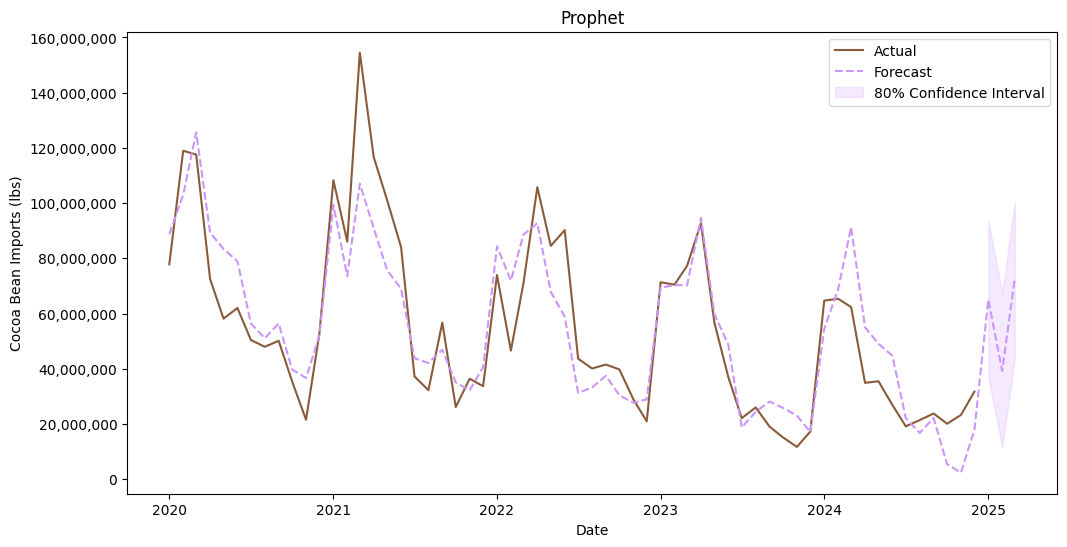

In [150]:
plt.figure(figsize=(12, 6))

plt.plot(df["ds"], df["y"], label="Actual", color=custom_palette[2])

plt.plot(forecast["ds"], forecast["yhat"], label="Forecast", color=custom_palette[0], linestyle='--')

future_forecast = forecast[forecast['ds'] > df['ds'].max()]
plt.fill_between(
    future_forecast['ds'],
    future_forecast['yhat_lower'],
    future_forecast['yhat_upper'],
    color=custom_palette[0], alpha=0.2, label='80% Confidence Interval'
)

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.legend()
plt.ylabel("Cocoa Bean Imports (lbs)")
plt.xlabel("Date")
plt.title("Prophet")
plt.show()


Prophet's Decomposition:

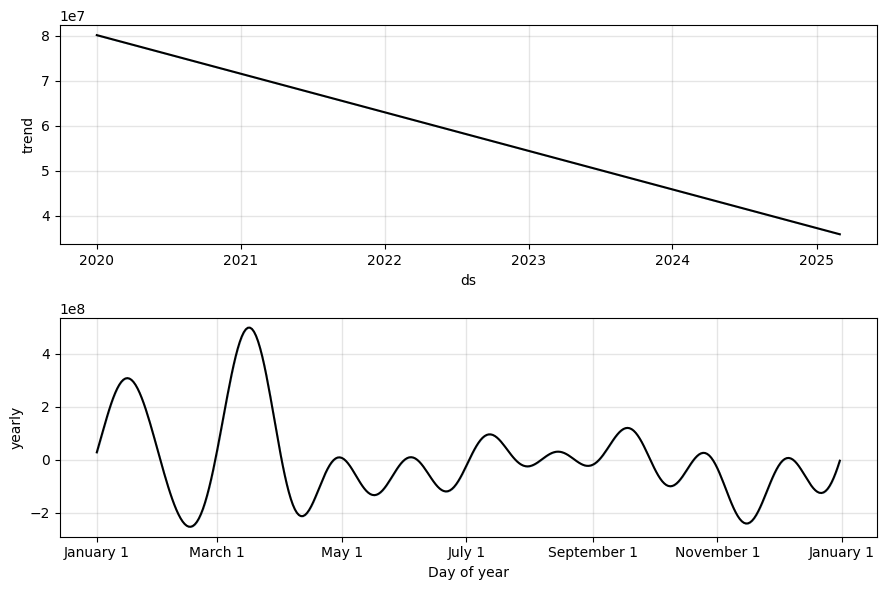

In [151]:
fig = m.plot_components(forecast)

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_color('black')
plt.show()


Cross validation for predicting rolling 1-3 months out from training data:


In [152]:
period = "1MS"  # Month start
cutoffs = pd.date_range(start="2023-09-01", end="2024-07-01", freq=period) # End is last starting date
horizon = "93 days"  # Forecast horizon for each cutoff
prophet_cv = cross_validation(m, cutoffs=cutoffs, horizon=horizon)

prophet_cv['AE'] = abs(prophet_cv['yhat'] - prophet_cv['y'])
prophet_cv['APE'] = abs(prophet_cv['yhat'] - prophet_cv['y']) / abs(prophet_cv['y'])

prophet_cv['ds'] = pd.to_datetime(prophet_cv['ds'])
prophet_cv['cutoff'] = pd.to_datetime(prophet_cv['cutoff'])
prophet_cv['horizon'] = prophet_cv['ds'].dt.to_period('M').astype(int) - prophet_cv['cutoff'].dt.to_period('M').astype(int)

prophet_cv.style.format({'ds':'{:%m-%d-%Y}','cutoff':'{:%m-%d-%Y}','y':'{:,.0f}','yhat':'{:,.0f}','yhat_lower':'{:,.0f}','yhat_upper':'{:,.0f}','AE': '{:,.0f}', 'APE': '{:.2f}'})

  0%|          | 0/11 [00:00<?, ?it/s]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff,AE,APE,horizon
0,10-01-2023,"34,571,294","6,058,623","63,933,739","15,172,388",09-01-2023,"19,398,906",1.28,1
1,11-01-2023,"36,122,420","9,531,922","61,502,036","11,741,002",09-01-2023,"24,381,418",2.08,2
2,12-01-2023,"6,271,949","-19,447,156","33,878,323","17,305,596",09-01-2023,"11,033,647",0.64,3
3,11-01-2023,"39,374,964","13,141,072","66,650,064","11,741,002",10-01-2023,"27,633,962",2.35,1
4,12-01-2023,"8,371,796","-17,999,524","33,715,419","17,305,596",10-01-2023,"8,933,800",0.52,2
5,01-01-2024,"50,233,151","24,706,266","75,491,935","64,702,033",10-01-2023,"14,468,882",0.22,3
6,12-01-2023,"14,152,574","-12,481,773","39,201,333","17,305,596",11-01-2023,"3,153,022",0.18,1
7,01-01-2024,"49,940,755","20,128,238","77,748,022","64,702,033",11-01-2023,"14,761,278",0.23,2
8,02-01-2024,"78,604,042","52,132,358","104,586,699","65,375,575",11-01-2023,"13,228,467",0.20,3
9,01-01-2024,"49,872,672","23,713,251","76,284,401","64,702,033",12-01-2023,"14,829,361",0.23,1


In [153]:
MAE_by_horizon = prophet_cv.groupby(['horizon'])['AE'].mean()
MAE_by_horizon = pd.DataFrame(MAE_by_horizon).rename(columns={'AE': 'MAE'})

MAPE_by_horizon = prophet_cv.groupby(['horizon'])['APE'].mean()
MAPE_by_horizon = pd.DataFrame(MAPE_by_horizon).rename(columns={'APE': 'MAPE'})

prophet_horizon_table = MAE_by_horizon.merge(MAPE_by_horizon, on='horizon')
prophet_horizon_table.style.format({'MAE': '{:,.0f}', 'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"18,344,322",69%
2,"17,100,378",59%
3,"17,223,965",52%


In [154]:
prophet_p = performance_metrics(prophet_cv, rolling_window=1)
prophet_p.style.format({
    'mse': '{:,.0f}',
    'rmse': '{:,.0f}',
    'mae': '{:,.0f}',
    'mape': '{:.0%}',
    'coverage': '{:.0%}',
    'mdape': '{:.0%}',
    'smape': '{:.0%}',
    'coverage' : '{:.0%}'
})

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,92 days 00:00:00,"453,339,460,452,734","21,291,770","17,556,222",60%,45%,50%,85%


In [155]:
prophet_overall_MAE  = prophet_cv['AE'].mean()
prophet_overall_MAPE = prophet_cv['APE'].mean()

print(f"MAE:{prophet_overall_MAE:,.0f}")
print(f"MAPE (%): {prophet_overall_MAPE:.0%}")

MAE:17,556,222
MAPE (%): 60%


Tuning the model:

Grid Search with hyperparameter options:

In [156]:
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.02],
    'changepoint_range': [0.8, 0.95],
    'seasonality_prior_scale': [0.1, 1.0, 5.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'growth': ['linear', 'logistic']
}

all_params = list(itertools.product(*param_grid.values()))
rmses = []

for params in all_params:
    param_dict = dict(zip(param_grid.keys(), params))
    temp_df = df.copy()

    if param_dict['growth'] == 'logistic':
        temp_df['floor'] = 0
        temp_df['cap'] = temp_df['y'].max() * 1.2

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False, interval_width=0.95,
        **param_dict
    )
    model.fit(temp_df)

    df_cv = cross_validation(model, cutoffs=cutoffs, horizon='93 days')
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].mean())

tuning_results = pd.DataFrame([dict(zip(param_grid.keys(), p)) for p in all_params])
tuning_results['rmse'] = rmses
print(tuning_results.nsmallest(1, 'rmse'))

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

...

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

    changepoint_prior_scale  changepoint_range  seasonality_prior_scale  \
26                     0.01                0.8                      0.1   

   seasonality_mode  growth          rmse  
26   multiplicative  linear  1.379411e+07  


Best parameters:

In [157]:
best_params_prep = all_params[np.argmin(rmses)]
best_params = dict(zip(param_grid.keys(), best_params_prep))

print(best_params)


{'changepoint_prior_scale': 0.01, 'changepoint_range': 0.8, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'growth': 'linear'}


Plot model fit and forecast, including floor and cap since seasonality mode chose 'multiplicative' - because it needs guardrails:

           ds          yhat    yhat_lower    yhat_upper
0  2020-01-01  9.962309e+07  6.704958e+07  1.320933e+08
1  2020-02-01  9.822106e+07  6.667767e+07  1.285981e+08
2  2020-03-01  1.212633e+08  9.037760e+07  1.520702e+08
3  2020-04-01  1.050092e+08  7.373332e+07  1.377121e+08
4  2020-05-01  8.638201e+07  5.602579e+07  1.169315e+08
..        ...           ...           ...           ...
58 2024-11-01  1.970418e+07 -9.057038e+06  5.147946e+07
59 2024-12-01  2.307426e+07 -6.296998e+06  5.483140e+07
60 2025-01-01  4.070195e+07  8.212993e+06  7.151133e+07
61 2025-02-01  3.952993e+07  7.271884e+06  7.093019e+07
62 2025-03-01  4.800308e+07  1.793707e+07  8.175535e+07

[63 rows x 4 columns]


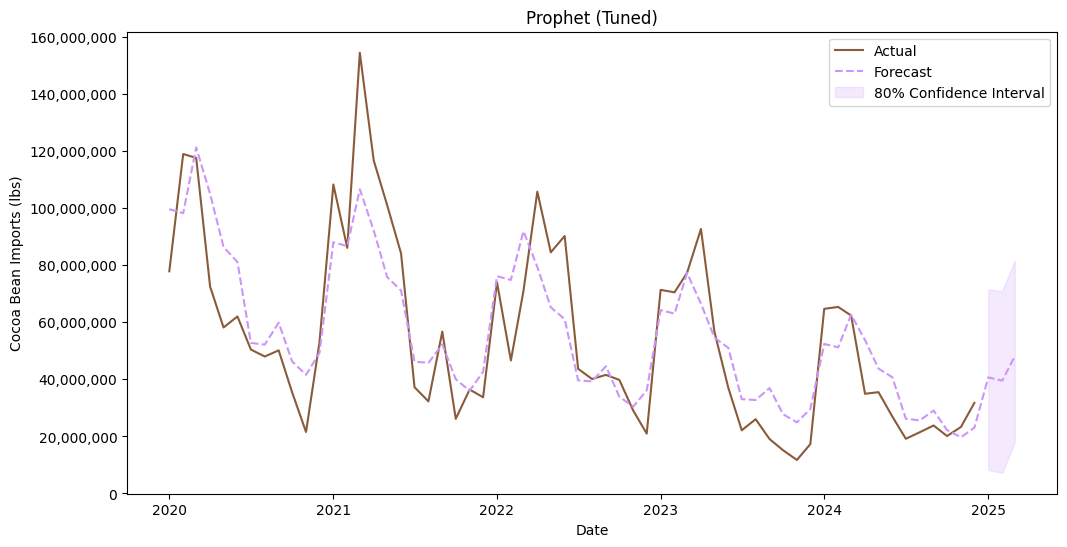

In [158]:
cap_value = df['y'].max() * 1.2

df = df.copy()
df['floor'] = 0
df['cap'] = cap_value

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False, interval_width=0.95,
    **best_params
)

m.fit(df)

future = m.make_future_dataframe(periods=3, freq='MS')
future['floor'] = 0
future['cap'] = cap_value

forecast = m.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

plt.figure(figsize=(12, 6))

plt.plot(df["ds"], df["y"], label="Actual", color=custom_palette[2])

plt.plot(forecast["ds"], forecast["yhat"], label="Forecast", color=custom_palette[0], linestyle='--')

future_forecast = forecast[forecast['ds'] > df['ds'].max()]
plt.fill_between(
    future_forecast['ds'],
    future_forecast['yhat_lower'],
    future_forecast['yhat_upper'],
    color=custom_palette[0], alpha=0.2, label='80% Confidence Interval'
)

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.legend()
plt.ylabel("Cocoa Bean Imports (lbs)")
plt.xlabel("Date")
plt.title("Prophet (Tuned)")
plt.show()


Cross validation for predicting rolling 1-3 months out from training data:


In [159]:
period = "1MS"  # Month start
cutoffs = pd.date_range(start="2023-09-01", end="2024-08-01", freq=period) # End is last starting date
horizon = "92 days"  # Forecast horizon for each cutoff
prophet_tuned_cv = cross_validation(m, cutoffs=cutoffs, horizon=horizon)

prophet_tuned_cv['AE'] = abs(prophet_tuned_cv['yhat'] - prophet_tuned_cv['y'])
prophet_tuned_cv['APE'] = (abs(prophet_tuned_cv['yhat'] - prophet_tuned_cv['y']) / abs(prophet_tuned_cv['y']))

prophet_tuned_cv['ds'] = pd.to_datetime(prophet_tuned_cv['ds'])
prophet_tuned_cv['cutoff'] = pd.to_datetime(prophet_tuned_cv['cutoff'])
prophet_tuned_cv['horizon'] = prophet_tuned_cv['ds'].dt.to_period('M').astype(int) - prophet_tuned_cv['cutoff'].dt.to_period('M').astype(int)
prophet_tuned_cv.style.format({'ds':'{:%m-%d-%Y}','cutoff':'{:%m-%d-%Y}','y':'{:,.0f}','yhat':'{:,.0f}','yhat_lower':'{:,.0f}','yhat_upper':'{:,.0f}','AE': '{:,.0f}', 'APE': '{:.0%}'})

  0%|          | 0/12 [00:00<?, ?it/s]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff,AE,APE,horizon
0,10-01-2023,"33,229,787","1,506,455","66,906,788","15,172,388",09-01-2023,"18,057,399",119%,1
1,11-01-2023,"29,595,579","-1,537,476","61,911,094","11,741,002",09-01-2023,"17,854,577",152%,2
2,12-01-2023,"33,518,306","-30,044","67,764,569","17,305,596",09-01-2023,"16,212,710",94%,3
3,11-01-2023,"29,070,280","-3,321,168","61,688,630","11,741,002",10-01-2023,"17,329,278",148%,1
4,12-01-2023,"32,972,679","815,843","65,657,758","17,305,596",10-01-2023,"15,667,083",91%,2
5,01-01-2024,"55,687,186","22,112,958","88,445,835","64,702,033",10-01-2023,"9,014,847",14%,3
6,12-01-2023,"32,629,136","-1,018,300","68,785,487","17,305,596",11-01-2023,"15,323,540",89%,1
7,01-01-2024,"54,859,769","20,987,515","91,568,909","64,702,033",11-01-2023,"9,842,264",15%,2
8,02-01-2024,"53,190,108","17,239,506","86,802,802","65,375,575",11-01-2023,"12,185,467",19%,3
9,01-01-2024,"53,960,554","20,028,755","86,771,328","64,702,033",12-01-2023,"10,741,479",17%,1


In [160]:
MAE_by_horizon = prophet_tuned_cv.groupby(['horizon'])['AE'].mean()
MAE_by_horizon = pd.DataFrame(MAE_by_horizon).rename(columns={'AE': 'MAE'})

MAPE_by_horizon = prophet_tuned_cv.groupby(['horizon'])['APE'].mean()
MAPE_by_horizon = pd.DataFrame(MAPE_by_horizon).rename(columns={'APE': 'MAPE'})

prophet_tuned_horizon_table = MAE_by_horizon.merge(MAPE_by_horizon,on='horizon')
prophet_tuned_horizon_table.style.format({'MAE': '{:,.0f}', 'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"12,449,653",54%
2,"11,544,815",47%
3,"10,537,687",37%


In [161]:
prophet_tuned_p = performance_metrics(prophet_tuned_cv, rolling_window=1)
prophet_tuned_p.style.format({
    'mse': '{:,.0f}',
    'rmse': '{:,.0f}',
    'mae': '{:,.0f}',
    'mape': '{:.0%}',
    'coverage': '{:.0%}',
    'mdape': '{:.0%}',
    'smape': '{:.0%}',
    'coverage' : '{:.0%}'
})


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,92 days 00:00:00,"175,730,234,526,690","13,256,328","11,510,718",46%,28%,34%,100%


Performance is not great:

In [162]:
prophet_tuned_overall_MAE  = prophet_tuned_cv['AE'].mean()
prophet_tuned_overall_MAPE = prophet_tuned_cv['APE'].mean()

print(f"MAE: {prophet_tuned_overall_MAE:,.0f}")
print(f"MAPE (%): {prophet_tuned_overall_MAPE:.0%}")

MAE: 11,510,718
MAPE (%): 46%


Prophet with log transformation:

In [163]:
df_log = df.copy()

df_log['y'] = np.log1p(df_log['y'])
df_log['floor'] = np.log1p(df_log['floor'])
df_log['cap'] = np.log1p(df_log['cap'])

df_log.head()

,ds,y,floor,cap
0,2020-01-01,18.170473,0.0,19.037795
1,2020-02-01,18.594360,0.0,19.037795
2,2020-03-01,18.582752,0.0,19.037795
3,2020-04-01,18.099428,0.0,19.037795
4,2020-05-01,17.879054,0.0,19.037795


In [164]:
df_log.head()

,ds,y,floor,cap
0,2020-01-01,18.170473,0.0,19.037795
1,2020-02-01,18.594360,0.0,19.037795
2,2020-03-01,18.582752,0.0,19.037795
3,2020-04-01,18.099428,0.0,19.037795
4,2020-05-01,17.879054,0.0,19.037795


In [165]:
param_grid_log = {
    'changepoint_prior_scale': [0.001, 0.01, 0.02],
    'changepoint_range': [0.8, 0.95],
    'seasonality_prior_scale': [0.1, 1.0, 5.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'growth': ['linear', 'logistic']
}

all_params_log = list(itertools.product(*param_grid_log.values()))
rmses_log = []

for params in all_params_log:
    param_dict_log = dict(zip(param_grid_log.keys(), params))

    if param_dict_log['growth'] == 'logistic':
        df_log['floor'] = 0
        df_log['cap'] = df_log['y'].max() * 1.2

    model_log = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False, interval_width=0.95,
        **param_dict
    )
    model_log.fit(df_log)

    cv_log = cross_validation(model_log, cutoffs=cutoffs, horizon='93 days')

    cv_orig = cv_log.copy()
    cv_orig['y_orig'] = np.expm1(cv_log['y'])
    cv_orig['yhat_orig'] = np.expm1(cv_log['yhat'])
    df_p_orig = performance_metrics(cv_orig, rolling_window=1)
    rmses_log.append(df_p_orig['rmse'].mean())

tuning_results_log = pd.DataFrame([dict(zip(param_grid_log.keys(), p)) for p in all_params_log])
tuning_results_log['rmse'] = rmses_log
print(tuning_results_log.nsmallest(1, 'rmse'))

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

   changepoint_prior_scale  changepoint_range  seasonality_prior_scale  \
0                    0.001                0.8                      0.1   

  seasonality_mode  growth      rmse  
0         additive  linear  0.445275  


In [166]:
best_params_prep_log = all_params_log[np.argmin(rmses_log)]
best_params_log = dict(zip(param_grid_log.keys(), best_params_prep_log))

print(best_params_log)


{'changepoint_prior_scale': 0.001, 'changepoint_range': 0.8, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'additive', 'growth': 'linear'}


In [167]:
cv_orig['AE'] = abs(cv_orig['yhat_orig'] - cv_orig['y_orig'])
cv_orig['APE'] = abs(cv_orig['yhat_orig'] - cv_orig['y_orig']) / abs(cv_orig['y_orig'])

In [168]:
cv_orig.style.format({
    'ds':'{:%m-%d-%Y}',
    'y':'{:,.2f}',
    'yhat':'{:,.2f}',
    'yhat_lower':'{:,.2f}',
    'yhat_upper':'{:,.2f}',
    'y_orig':'{:,.0f}',
    'cutoff':'{:%m-%d-%Y}',
    'yhat_orig':'{:,.0f}',
    'yhat_lower_orig':'{:,.0f}',
    'yhat_upper_orig':'{:,.0f}',
    'AE': '{:,.0f}',
    'APE': '{:.0%}'
})

,ds,yhat,yhat_lower,yhat_upper,y,cutoff,y_orig,yhat_orig,AE,APE
0,10-01-2023,17.47,17.04,17.86,16.53,09-01-2023,"15,172,388","38,590,834","23,418,446",154%
1,11-01-2023,17.49,17.10,17.87,16.28,09-01-2023,"11,741,002","39,427,057","27,686,055",236%
2,12-01-2023,16.42,16.00,16.82,16.67,09-01-2023,"17,305,596","13,487,254","3,818,342",22%
3,11-01-2023,17.64,17.20,18.08,16.28,10-01-2023,"11,741,002","45,868,911","34,127,909",291%
4,12-01-2023,16.51,16.07,16.91,16.67,10-01-2023,"17,305,596","14,822,750","2,482,846",14%
5,01-01-2024,17.57,17.14,17.97,17.99,10-01-2023,"64,702,033","42,504,469","22,197,564",34%
6,12-01-2023,16.81,16.35,17.33,16.67,11-01-2023,"17,305,596","19,974,893","2,669,297",15%
7,01-01-2024,17.57,17.09,18.04,17.99,11-01-2023,"64,702,033","42,553,648","22,148,385",34%
8,02-01-2024,17.75,17.28,18.26,18.00,11-01-2023,"65,375,575","51,167,441","14,208,134",22%
9,01-01-2024,17.58,17.06,18.07,17.99,12-01-2023,"64,702,033","43,184,338","21,517,695",33%


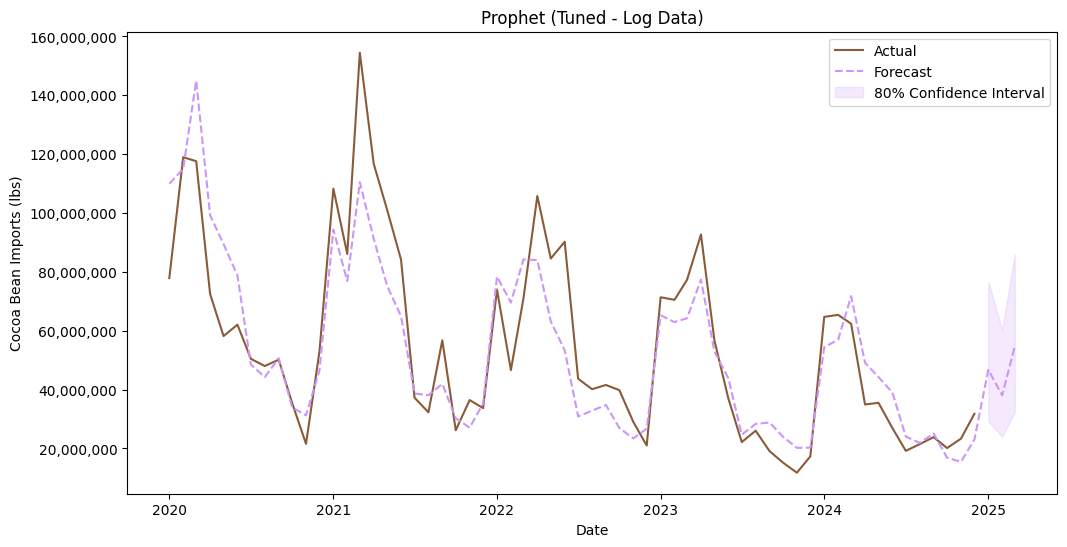

In [169]:
m_log = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False, interval_width=0.95,
    **best_params_log
)

m_log.fit(df_log)

future_log = m_log.make_future_dataframe(periods=3, freq='MS')
future_log['floor'] = np.log1p(0)
future_log['cap'] = np.log1p(cap_value)

forecast_log = m_log.predict(future_log)

forecast_log['yhat_orig'] = np.expm1(forecast_log['yhat'])
forecast_log['yhat_lower_orig'] = np.expm1(forecast_log['yhat_lower'])
forecast_log['yhat_upper_orig'] = np.expm1(forecast_log['yhat_upper'])

plt.figure(figsize=(12, 6))

plt.plot(df['ds'], df['y'], label="Actual", color=custom_palette[2])

plt.plot(forecast_log['ds'], forecast_log['yhat_orig'], label="Forecast", color=custom_palette[0], linestyle='--')

future_forecast_log = forecast_log[forecast_log['ds'] > df_log['ds'].max()]
plt.fill_between(
    future_forecast_log['ds'],
    future_forecast_log['yhat_lower_orig'],
    future_forecast_log['yhat_upper_orig'],
    color=custom_palette[0],
    alpha=0.2,
    label='80% Confidence Interval'
)

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.legend()
plt.ylabel("Cocoa Bean Imports (lbs)")
plt.xlabel("Date")
plt.title("Prophet (Tuned - Log Data)")
plt.show()

In [170]:
prophet_tuned_log_cv= cv_orig

prophet_tuned_log_cv['AE'] = abs(prophet_tuned_log_cv['yhat_orig'] - prophet_tuned_log_cv['y_orig'])
prophet_tuned_log_cv['APE'] = (abs(prophet_tuned_log_cv['yhat_orig'] - prophet_tuned_log_cv['y_orig']) / abs(prophet_tuned_log_cv['y_orig']))

prophet_tuned_log_cv['ds'] = pd.to_datetime(prophet_tuned_log_cv['ds'])
prophet_tuned_log_cv['cutoff'] = pd.to_datetime(prophet_tuned_log_cv['cutoff'])
prophet_tuned_log_cv['horizon'] = prophet_tuned_log_cv['ds'].dt.to_period('M').astype(int) - prophet_tuned_log_cv['cutoff'].dt.to_period('M').astype(int)
prophet_tuned_log_cv.style.format({'ds':'{:%m-%d-%Y}','cutoff':'{:%m-%d-%Y}','y':'{:,.2f}','y_orig':'{:,.0f}','yhat':'{:,.2f}','yhat_lower':'{:,.2f}',
                                   'yhat_upper':'{:,.2f}','yhat_orig':'{:,.0f}','yhat_lower_orig':'{:,.0f}',
                                   'yhat_upper_orig':'{:,.0f}','AE': '{:,.0f}', 'APE': '{:.0%}'})


,ds,yhat,yhat_lower,yhat_upper,y,cutoff,y_orig,yhat_orig,AE,APE,horizon
0,10-01-2023,17.47,17.04,17.86,16.53,09-01-2023,"15,172,388","38,590,834","23,418,446",154%,1
1,11-01-2023,17.49,17.10,17.87,16.28,09-01-2023,"11,741,002","39,427,057","27,686,055",236%,2
2,12-01-2023,16.42,16.00,16.82,16.67,09-01-2023,"17,305,596","13,487,254","3,818,342",22%,3
3,11-01-2023,17.64,17.20,18.08,16.28,10-01-2023,"11,741,002","45,868,911","34,127,909",291%,1
4,12-01-2023,16.51,16.07,16.91,16.67,10-01-2023,"17,305,596","14,822,750","2,482,846",14%,2
5,01-01-2024,17.57,17.14,17.97,17.99,10-01-2023,"64,702,033","42,504,469","22,197,564",34%,3
6,12-01-2023,16.81,16.35,17.33,16.67,11-01-2023,"17,305,596","19,974,893","2,669,297",15%,1
7,01-01-2024,17.57,17.09,18.04,17.99,11-01-2023,"64,702,033","42,553,648","22,148,385",34%,2
8,02-01-2024,17.75,17.28,18.26,18.00,11-01-2023,"65,375,575","51,167,441","14,208,134",22%,3
9,01-01-2024,17.58,17.06,18.07,17.99,12-01-2023,"64,702,033","43,184,338","21,517,695",33%,1


In [171]:
MAE_by_horizon_log = prophet_tuned_log_cv.groupby(['horizon'])['AE'].mean()
MAE_by_horizon_log = pd.DataFrame(MAE_by_horizon_log).rename(columns={'AE': 'MAE'})

MAPE_by_horizon_log = prophet_tuned_log_cv.groupby(['horizon'])['APE'].mean()
MAPE_by_horizon_log = pd.DataFrame(MAPE_by_horizon_log).rename(columns={'APE': 'MAPE'})

prophet_tuned_log_horizon_table = MAE_by_horizon_log.merge(MAPE_by_horizon_log,on='horizon')
prophet_tuned_log_horizon_table.style.format({'MAE': '{:,.0f}', 'MAPE': '{:.0%}'})

,MAE,MAPE
horizon,,
1,"13,120,463",59%
2,"11,264,117",44%
3,"9,616,237",29%


The log transformation did not meaningfully improve the performance:

In [172]:
prophet_tuned_log_overall_MAE  = prophet_tuned_log_cv['AE'].mean()
prophet_tuned_log_overall_MAPE = prophet_tuned_log_cv['APE'].mean()

print(f"MAE:{prophet_tuned_log_overall_MAE:,.0f}")
print(f"MAPE (%):{prophet_tuned_log_overall_MAPE:.0%}")

MAE:11,333,605
MAPE (%):44%


#Model Selection

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/ModelSelection.png)

Overall Model Metrics:

Note, only includes the tuned models above (and excludes the ETS model which was just used as a CI double-check):

In [173]:
final_table = pd.DataFrame({
    'Model': [
        'ExponentialSmoothing','ExponentialSmoothing',
        'Sarima','Sarima','Sarima','Sarima','Sarima','Sarima',
        'Prophet','Prophet'
    ],
    'Log Data': ['N','Y','N','N','N','Y','Y','Y','N','Y'],
    'Tuning': [
        'Manual','Manual',
        'Short Grid Search','Grid Search','Manual',
        'Short Grid Search','Grid Search','Manual',
        'Grid Search','Grid Search'
    ],

    'MAE': [
        exp_ts_tuned_overall_MAE,
        exp_ts_tuned_log_overall_MAE,
        sarima_auto_overall_MAE,
        sarima_flex_full_overall_MAE,
        sarima_manual_overall_MAE,
        sarima_log_auto_overall_MAE,
        sarima_log_full_flex_overall_MAE,
        sarima_log_manual_overall_MAE,
        prophet_tuned_overall_MAE,
        prophet_tuned_log_overall_MAE
    ],

    'MAPE': [
        exp_ts_tuned_overall_MAPE,
        exp_ts_tuned_log_overall_MAPE,
        sarima_auto_overall_MAPE,
        sarima_flex_full_overall_MAPE,
        sarima_manual_overall_MAPE,
        sarima_log_auto_overall_MAPE,
        sarima_log_full_flex_overall_MAPE,
        sarima_log_manual_overall_MAPE,
        prophet_tuned_overall_MAPE,
        prophet_tuned_log_overall_MAPE
    ],

    'MAE_H1': [
        exp_ts_tuned_cv['MAE'][1],
        exp_ts_tuned_log_cv['MAE'][1],
        sarima_auto_cv['MAE'][1],
        sarima_flex_full_cv['MAE'][1],
        sarima_manual_cv['MAE'][1],
        sarima_log_auto_cv['MAE'][1],
        sarima_log_full_flex_cv['MAE'][1],
        sarima_log_manual_cv['MAE'][1],
        prophet_tuned_horizon_table['MAE'][1],
        prophet_tuned_log_horizon_table['MAE'][1]
    ],

    'MAE_H2': [
        exp_ts_tuned_cv['MAE'][2],
        exp_ts_tuned_log_cv['MAE'][2],
        sarima_auto_cv['MAE'][2],
        sarima_flex_full_cv['MAE'][2],
        sarima_manual_cv['MAE'][2],
        sarima_log_auto_cv['MAE'][2],
        sarima_log_full_flex_cv['MAE'][2],
        sarima_log_manual_cv['MAE'][2],
        prophet_tuned_horizon_table['MAE'][2],
        prophet_tuned_log_horizon_table['MAE'][2]
    ],

    'MAE_H3': [
        exp_ts_tuned_cv['MAE'][3],
        exp_ts_tuned_log_cv['MAE'][3],
        sarima_auto_cv['MAE'][3],
        sarima_flex_full_cv['MAE'][3],
        sarima_manual_cv['MAE'][3],
        sarima_log_auto_cv['MAE'][3],
        sarima_log_full_flex_cv['MAE'][3],
        sarima_log_manual_cv['MAE'][3],
        prophet_tuned_horizon_table['MAE'][3],
        prophet_tuned_log_horizon_table['MAE'][3]
    ],

    'MAPE_H1': [
        exp_ts_tuned_cv['MAPE'][1],
        exp_ts_tuned_log_cv['MAPE'][1],
        sarima_auto_cv['MAPE'][1],
        sarima_flex_full_cv['MAPE'][1],
        sarima_manual_cv['MAPE'][1],
        sarima_log_auto_cv['MAPE'][1],
        sarima_log_full_flex_cv['MAPE'][1],
        sarima_log_manual_cv['MAPE'][1],
        prophet_tuned_horizon_table['MAPE'][1],
        prophet_tuned_log_horizon_table['MAPE'][1]
    ],

    'MAPE_H2': [
        exp_ts_tuned_cv['MAPE'][2],
        exp_ts_tuned_log_cv['MAPE'][2],
        sarima_auto_cv['MAPE'][2],
        sarima_flex_full_cv['MAPE'][2],
        sarima_manual_cv['MAPE'][2],
        sarima_log_auto_cv['MAPE'][2],
        sarima_log_full_flex_cv['MAPE'][2],
        sarima_log_manual_cv['MAPE'][2],
        prophet_tuned_horizon_table['MAPE'][2],
        prophet_tuned_log_horizon_table['MAPE'][2]
    ],

    'MAPE_H3': [
        exp_ts_tuned_cv['MAPE'][3],
        exp_ts_tuned_log_cv['MAPE'][3],
        sarima_auto_cv['MAPE'][3],
        sarima_flex_full_cv['MAPE'][3],
        sarima_manual_cv['MAPE'][3],
        sarima_log_auto_cv['MAPE'][3],
        sarima_log_full_flex_cv['MAPE'][3],
        sarima_log_manual_cv['MAPE'][3],
        prophet_tuned_horizon_table['MAPE'][3],
        prophet_tuned_log_horizon_table['MAPE'][3]
    ]
})


In [174]:
final_table.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}',
    'MAE_H1': '{:,.0f}',
    'MAE_H2': '{:,.0f}',
    'MAE_H3': '{:,.0f}',
    'MAPE': '{:.0%}',
    'MAPE_H1': '{:.0%}',
    'MAPE_H2': '{:.0%}',
    'MAPE_H3': '{:.0%}'
})


,Model,Log Data,Tuning,MAE,MAPE,MAE_H1,MAE_H2,MAE_H3,MAPE_H1,MAPE_H2,MAPE_H3
0,ExponentialSmoothing,N,Manual,"9,559,131",27%,"8,232,452","9,662,805","10,782,135",24%,29%,30%
1,ExponentialSmoothing,Y,Manual,"10,529,673",29%,"8,454,657","10,832,715","12,301,647",24%,30%,33%
2,Sarima,N,Short Grid Search,"17,625,899",67%,"11,563,515","18,363,968","22,950,214",40%,72%,88%
3,Sarima,N,Grid Search,"9,843,491",33%,"8,015,458","10,640,699","10,874,315",29%,37%,33%
4,Sarima,N,Manual,"22,289,323",92%,"16,481,080","23,139,193","27,247,696",72%,99%,105%
5,Sarima,Y,Short Grid Search,"9,876,090",27%,"8,183,549","9,969,859","11,474,863",22%,27%,31%
6,Sarima,Y,Grid Search,"9,886,487",29%,"7,851,162","10,110,756","11,697,541",23%,31%,32%
7,Sarima,Y,Manual,"10,271,880",29%,"8,358,623","10,539,407","11,917,611",24%,30%,33%
8,Prophet,N,Grid Search,"11,510,718",46%,"12,449,653","11,544,815","10,537,687",54%,47%,37%
9,Prophet,Y,Grid Search,"11,333,605",44%,"13,120,463","11,264,117","9,616,237",59%,44%,29%


#Results

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Results.png)

The Triple Exponential Smoothing (Tuned - note only tuned models were in the final table), non-log transformed data model performed the best with 27 % overall MAPE but also the lowest MAE across horizons 1, 2, & 3 (per the table above). I looked at MAE and MAPE together when evaluating. Prophet surprisingly performed poorly. SARIMA was quite comparable for its best model but had results all across the board depending on the adjustments.

In [175]:
final_model=final_table.iloc[[0]]
final_model.style.format({
    'MAE': '{:,.0f}',
    'MAPE': '{:.0%}',
    'MAE_H1': '{:,.0f}',
    'MAE_H2': '{:,.0f}',
    'MAE_H3': '{:,.0f}',
    'MAPE': '{:.0%}',
    'MAPE_H1': '{:.0%}',
    'MAPE_H2': '{:.0%}',
    'MAPE_H3': '{:.0%}'
})

,Model,Log Data,Tuning,MAE,MAPE,MAE_H1,MAE_H2,MAE_H3,MAPE_H1,MAPE_H2,MAPE_H3
0,ExponentialSmoothing,N,Manual,"9,559,131",27%,"8,232,452","9,662,805","10,782,135",24%,29%,30%


In [176]:
display(Image(url="https://raw.githubusercontent.com/lindsayalexandra14/ds_portfolio/main/1_projects/machine_learning/time_series_and_survival/cocoa_imports/cocoa_imports_final_model_plot.png",
    width=800))

The best predictions of US Cocoa Bean Imports for the 1st 3 months of 2025 are:

| Date       | Forecast | Lower_CI | Upper_CI |
|------------|----------|----------|----------|
| 2025-01-01 | 59,915,879 | 31,650,287 | 67,112,957 |
| 2025-02-01 | 59,477,191 | 30,411,927 | 65,506,481 |
| 2025-03-01 | 75,993,848 | 38,341,516 | 84,996,332 |


Future Improvements:

Additions on this project could include adding additional regressors, like the global market price of Cocoa Beans or the supply, and/or forecasting by country or continent. Removing outliers by country first may also improve performance, however recent anomalies due to supply or price may continue moving forward and removing them may be detrimental.